In [1]:
from recbole.quick_start import load_data_and_model, run_recbole
import torch
import pandas as pd


import torch
from recbole.config import Config
from recbole.data import create_dataset, data_preparation
from recbole.model.general_recommender import NeuMF
from recbole.trainer import Trainer
from recbole.utils import get_model, get_trainer, init_seed, init_logger


/home/mvarasteh/.conda/envs/popsteer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-04 09:36:45,216	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-05-04 09:36:45,450	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
dataset_name='ml-1m'

In [ ]:
config = Config(
    model='SASRec',
    dataset='ml-1m',   
    config_file_list=['configs/SASRec_ml-1m.yaml'])


# Init seed and logger
init_seed(config['seed'], config['reproducibility'])
init_logger(config)

# Load dataset and map user/item IDs
dataset = create_dataset(config)

print(f"Num users: {dataset.user_num}, Num items: {dataset.item_num}")


# Split into train/valid/test and build user-item mappings
train_data, valid_data, test_data = data_preparation(config, dataset)

# Build model
model = NeuMF(config, train_data.dataset).to(config['device'])

# Build trainer
trainer = Trainer(config, model)

# Train the model
best_valid_score, best_valid_result = trainer.fit(
    train_data,
    valid_data,
    saved=True,          # saves best checkpoint
    show_progress=True   # progress bar per epoch
)

print(f"Best validation score: {best_valid_score}")
print(f"Best validation result: {best_valid_result}")



In [3]:
import torch
import numpy as np
import pandas as pd
from collections import defaultdict

# ── 0. LOAD MODEL AND DATASET ───────────────────────────────────────────────
from recbole.quick_start import load_data_and_model

config, model, dataset, train_data, valid_data, test_data = load_data_and_model(
    model_file='saved/sasrec_ml-1m.pth'
)
model.eval()
device = config['device']

04 May 09:36    INFO  
General Hyper Parameters:
gpu_id = 0
use_gpu = True
seed = 2020
state = INFO
reproducibility = True
data_path =

 dataset/ml-1mm
checkpoint_dir = saved
show_progress = True
save_dataset = False
dataset_save_path = None
save_dataloaders = False
dataloaders_save_path = None
log_wandb = False

Training Hyper Parameters:
epochs = 300
train_batch_size = 2048
learner = adam
learning_rate = 0.001
train_neg_sample_args = {'distribution': 'none', 'sample_num': 'none', 'alpha': 'none', 'dynamic': False, 'candidate_num': 0}
eval_step = 1
stopping_step = 10
clip_grad_norm = None
weight_decay = 0.0
loss_decimal_place = 4

Evaluation Hyper Parameters:
eval_args = {'split': {'LS': 'valid_and_test'}, 'order': 'TO', 'group_by': 'user', 'mode': {'valid': 'full', 'test': 'full'}}
repeatable = True
metrics = ['Recall', 'NDCG', 'Hit', 'Deep_LT_Coverage', 'GiniIndex', 'AveragePopularity', 'ItemCoverage', 'NDCGTail', 'NDCGHead', 'NDCGMid']
topk = [10]
valid_metric = NDCG@10
valid_metric_bigger = True
eval_batch_size = 4096
metric_decimal_place = 4

Dataset Hyper Parameters:
field_separator = 	
seq_separator =  
USER_ID

## Extracting embeddings

In [4]:
import torch
import numpy as np
import pandas as pd
from collections import defaultdict



model.eval()
device = config['device']

# ── 1. LOAD RAW METADATA ────────────────────────────────────────────────────
# read the raw file and inspect first

movies = pd.read_csv(
    'dataset/ml-1mm/ml-1mm.item',
    sep='\t',
    engine='python'
)

# rename to simple names
movies = movies.rename(columns={
    'item_id:token':        'item_id',
    'movie_title:token_seq': 'title',
    'release_year:token':   'year',
    'genre:token_seq':      'genre'
})

# genres are space-separated in this file (not pipe-separated)
# e.g. "Animation Children's Comedy" instead of "Animation|Children|Comedy"
# so split on space when building genre pools


ratings = pd.read_csv(
    'dataset/ml-1mm/ml-1mm.inter',
    sep='\t',
    engine='python'
)


# rename to simple names
ratings = ratings.rename(columns={
    'user_id:token':    'user_id',
    'item_id:token':    'item_id',
    'rating:float':     'rating',
    'timestamp:float':  'timestamp'
})


# map raw item IDs to RecBole internal IDs
item_id_map = dataset.field2token_id['item_id']
movies['internal_id'] = movies['item_id'].astype(str).map(item_id_map)
movies = movies.dropna(subset=['internal_id'])
movies['internal_id'] = movies['internal_id'].astype(int)
movies = movies.sort_values('internal_id').reset_index(drop=True)



n_items = dataset.item_num
n_users = dataset.user_num



# ── 2. DEFINE CONCEPT ITEM POOLS ────────────────────────────────────────────
# split each genre string by space, flatten, and deduplicate
all_unique_genres = sorted(set(
    g.strip()
    for genres in movies['genre'].dropna()
    for g in str(genres).split(' ')
    if g.strip()
))


# genre pools — items belonging to each genre
genre_pools = defaultdict(list)
for _, row in movies.iterrows():
    iid = int(row['internal_id'])
    for g in str(row['genre']).split(' '):   
        g = g.strip()
        if g in all_unique_genres:                 
            genre_pools[g].append(iid )



In [5]:
# popularity pool — top 10% most interacted items
inter_df = pd.DataFrame({
    'user_id': dataset.inter_feat['user_id'].numpy(),
    'item_id': dataset.inter_feat['item_id'].numpy(),
})


item_counts = inter_df.groupby('item_id')['user_id'].count()
pop_map = {}
for raw_id, count in item_counts.items():
    #iid = item_id_map.get(str(raw_id))
    iid = int(raw_id)

    if iid is not None:
        pop_map[int(iid)] = count

counts_arr = np.array([pop_map.get(i, 0) for i in range(n_items)])
pop_threshold = np.percentile(counts_arr, 90)
popularity_pool = [i for i in range(n_items) if counts_arr[i] >= pop_threshold]

In [6]:
# niche pool — bottom 20% least interacted items
niche_threshold = np.percentile(counts_arr, 10)
niche_pool = [i for i in range(n_items) if 0 < counts_arr[i] <= niche_threshold]


In [7]:
# era pools
movies['year'] = pd.to_numeric(movies['year'], errors='coerce')

#classic_pool   = [int(r['internal_id']) for _, r in movies.iterrows() if r['year'] < 1970]
#retro_pool     = [int(r['internal_id']) for _, r in movies.iterrows() if 1970 <= r['year'] < 1990]
#modern_pool    = [int(r['internal_id']) for _, r in movies.iterrows() if 1990 <= r['year'] < 2000]
#contemporary_pool = [int(r['internal_id']) for _, r in movies.iterrows() if r['year'] >= 2000]



classic_pool   = [int(r['internal_id']) for _, r in movies.iterrows() if r['year'] < 1989]
modern_pool    = [int(r['internal_id']) for _, r in movies.iterrows() if 1990 <= r['year'] < 9999]






## Combining concepts

In [8]:
concept_pools = {g: genre_pools[g] for g in all_unique_genres}
concept_pools['popularity']   = popularity_pool
concept_pools['niche']        = niche_pool


concept_pools['classic']      = classic_pool
#concept_pools['retro']        = retro_pool
concept_pools['modern']       = modern_pool
#concept_pools['contemporary'] = contemporary_pool

## CONCEPT PROTOTYPE VECTORS 

In [9]:

# ── 3. SYNTHETIC USER FORWARD PASS (SASRec) ─────────────────────────────────
N_SYNTHETIC = 1000
K_ITEMS     = 50  # matches SASRec's max_seq_length

def get_synthetic_user_repr_sasrec(item_pool, n_synthetic, k_items, model, device):
    """
    For each synthetic user:
      1. Sample a sequence of K items from the concept pool
      2. Left-align in a max_seq_len tensor (pad with 0 on the right)
      3. Run through SASRec → get 128-dim final hidden state
    Returns: tensor [n_synthetic, hidden_size]
    """
    user_reprs = []
    item_pool_tensor = torch.tensor(item_pool, dtype=torch.long)
    max_seq_len = model.max_seq_length  # 50

    model.eval()
    with torch.no_grad():
        for _ in range(n_synthetic):
            # sample K items as the user's interaction sequence
            sampled_idx = torch.randint(0, len(item_pool), (k_items,))
            sequence    = item_pool_tensor[sampled_idx]

            seq_len = min(k_items, max_seq_len)

            # left-align: items at positions 0..seq_len-1, pad with 0 on the right
            padded = torch.zeros(max_seq_len, dtype=torch.long)
            padded[:seq_len] = sequence[:seq_len]

            seq_tensor     = padded.unsqueeze(0).to(device)                        # [1, 50]
            seq_len_tensor = torch.tensor([seq_len], dtype=torch.long).to(device)  # [1]

            # SASRec forward returns [1, hidden_size] directly
            seq_output = model.forward(seq_tensor, seq_len_tensor)  # [1, 128]

            user_reprs.append(seq_output.squeeze(0).cpu())

    return torch.stack(user_reprs, dim=0)  # [n_synthetic, 128]


# ── 4. COMPUTE CONCEPT PROTOTYPE VECTORS ────────────────────────────────────
concept_prototypes  = {}
concept_all_vectors = {}

for concept, pool in concept_pools.items():
    if len(pool) < K_ITEMS:
        print(f"Skipping {concept} — pool too small ({len(pool)} items)")
        continue

    # exclude padding ID just in case
    pool = [i for i in pool if i != 0]

    print(f"Processing concept: {concept} ...")
    vecs      = get_synthetic_user_repr_sasrec(pool, N_SYNTHETIC, K_ITEMS, model, device)
    prototype = vecs.mean(dim=0)

    concept_all_vectors[concept] = vecs
    concept_prototypes[concept]  = prototype
    print(f"  {concept:20s}: vectors {vecs.shape}, prototype {prototype.shape}")

# ── 5. SAVE EVERYTHING ──────────────────────────────────────────────────────
torch.save({
    'concept_prototypes':  concept_prototypes,
    'concept_all_vectors': concept_all_vectors,
    'concept_names':       list(concept_prototypes.keys()),
    'n_synthetic':         N_SYNTHETIC,
    'k_items':             K_ITEMS,
    'hidden_size':         model.hidden_size,
    'model_type':          'SASRec',
}, f'concept_activations_sasrec_{dataset_name}.pt')

print("\nSaved to concept_activations_sasrec.pt")

# ── 6. SANITY CHECK ─────────────────────────────────────────────────────────
print("\nPrototype norms:")
for concept, proto in concept_prototypes.items():
    print(f"  {concept:20s}: norm = {proto.norm():.4f}")

print("\nCosine similarity between selected concepts:")
concepts_to_compare = ['Drama', 'Action', 'Romance', 'Horror', 'popularity', 'niche']
concepts_to_compare = [c for c in concepts_to_compare if c in concept_prototypes]

for i, c1 in enumerate(concepts_to_compare):
    for c2 in concepts_to_compare[i+1:]:
        v1  = concept_prototypes[c1]
        v2  = concept_prototypes[c2]
        sim = torch.nn.functional.cosine_similarity(v1.unsqueeze(0), v2.unsqueeze(0))
        print(f"  {c1:15s} vs {c2:15s}: {sim.item():.3f}")

# ── 7. DIFFERENCE CHECK ─────────────────────────────────────────────────────
# verify prototypes actually differ across concepts
print("\nL2 distance between concepts (should be non-zero):")
for c1 in ['Drama', 'Action']:
    for c2 in ['Romance', 'Horror', 'Animation']:
        if c1 in concept_prototypes and c2 in concept_prototypes:
            dist = (concept_prototypes[c1] - concept_prototypes[c2]).norm().item()
            print(f"  {c1:10s} vs {c2:10s}: {dist:.4f}")

Processing concept: Action ...
  Action              : vectors torch.Size([1000, 128]), prototype torch.Size([128])
Processing concept: Adventure ...
  Adventure           : vectors torch.Size([1000, 128]), prototype torch.Size([128])
Processing concept: Animation ...
  Animation           : vectors torch.Size([1000, 128]), prototype torch.Size([128])
Processing concept: Children's ...
  Children's          : vectors torch.Size([1000, 128]), prototype torch.Size([128])
Processing concept: Comedy ...
  Comedy              : vectors torch.Size([1000, 128]), prototype torch.Size([128])
Processing concept: Crime ...
  Crime               : vectors torch.Size([1000, 128]), prototype torch.Size([128])
Processing concept: Documentary ...
  Documentary         : vectors torch.Size([1000, 128]), prototype torch.Size([128])
Processing concept: Drama ...
  Drama               : vectors torch.Size([1000, 128]), prototype torch.Size([128])
Processing concept: Fantasy ...
  Fantasy             : vec

In [21]:
concept_prototypes.keys()

dict_keys(['Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western', 'popularity', 'niche', 'classic', 'modern'])

/home/mvarasteh/.conda/envs/popsteer/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP output shape: (2002, 2)


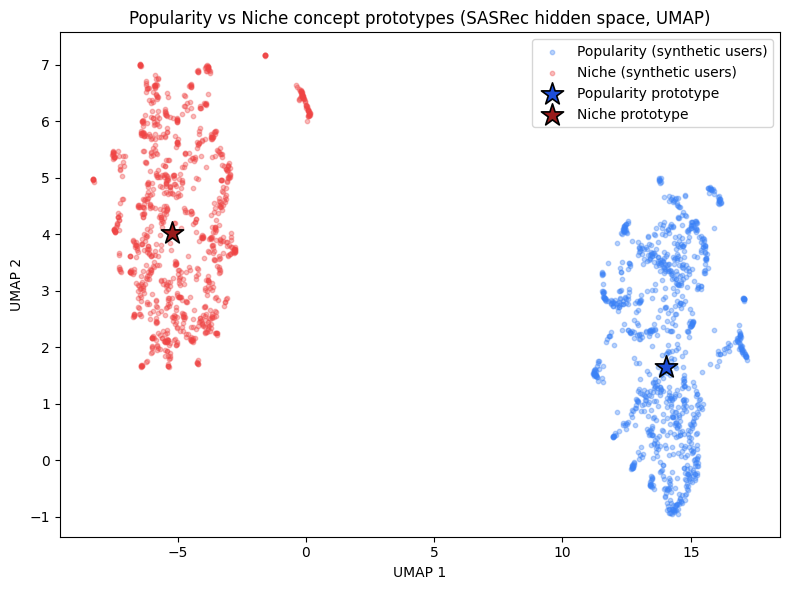

In [30]:
# ── PLOT POPULARITY vs NICHE PROTOTYPES (UMAP) ──────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import umap

# 1. Pull the cached vectors and prototypes
pop_reprs   = concept_all_vectors['popularity'].numpy()   # [1000, 128]
niche_reprs = concept_all_vectors['niche'].numpy()        # [1000, 128]

pop_proto   = concept_prototypes['popularity'].numpy().reshape(1, -1)
niche_proto = concept_prototypes['niche'].numpy().reshape(1, -1)
# 2. Stack and fit UMAP jointly so coords are comparable
X = np.vstack([pop_reprs, niche_reprs, pop_proto, niche_proto])

reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, metric='cosine', random_state=42)
X_2d = reducer.fit_transform(X)
print(f"UMAP output shape: {X_2d.shape}")
n = N_SYNTHETIC
pop_2d         = X_2d[:n]
niche_2d       = X_2d[n:2*n]
pop_proto_2d   = X_2d[2*n]
niche_proto_2d = X_2d[2*n + 1]

# 3. Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(pop_2d[:, 0],   pop_2d[:, 1],   s=10, alpha=0.35,
           color='#3b82f6', label='Popularity (synthetic users)')
ax.scatter(niche_2d[:, 0], niche_2d[:, 1], s=10, alpha=0.35,
           color='#ef4444', label='Niche (synthetic users)')
ax.scatter(*pop_proto_2d,   s=280, marker='*', color='#1d4ed8',
           edgecolor='black', linewidth=1.2, label='Popularity prototype', zorder=5)
ax.scatter(*niche_proto_2d, s=280, marker='*', color='#991b1b',
           edgecolor='black', linewidth=1.2, label='Niche prototype', zorder=5)

ax.set_title('Popularity vs Niche concept prototypes (SASRec hidden space, UMAP)')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(loc='best', frameon=True)
plt.tight_layout(); plt.show()



In [11]:
concept_prototypes

{'Action': tensor([ 0.3068,  0.1903, -0.2104,  0.7479,  0.2890, -0.1533,  0.0942,  0.4919,
          0.2381, -2.8711,  0.3124, -0.1461,  0.4207, -0.2436, -0.1246,  0.4112,
         -0.3470,  0.2701, -0.0614, -0.2615, -0.3924,  2.3801,  0.0507, -0.0998,
         -0.1048, -0.1846,  0.2362,  0.8703,  0.1911, -0.0382,  0.2732,  0.7224,
         -0.7655, -0.2141, -0.0645,  0.1167, -0.3450, -0.2716,  0.4192, -0.1664,
          0.0852,  0.0085,  0.1836, -0.2724, -0.2925,  1.0215,  0.2146,  0.0533,
         -0.4101, -0.1827, -0.1105,  0.4130, -1.4524,  0.2510, -0.1018,  0.1928,
          0.0821, -0.2835, -0.2789,  0.1443, -0.3843,  0.1170, -0.1402,  0.1997,
         -0.9546, -0.3350,  0.0515,  0.0346, -0.3081,  0.2323, -0.3422,  0.0944,
          0.0771,  0.0211,  0.4456, -4.5230, -0.6852,  0.0642, -0.1152,  0.3409,
          0.1627,  0.0338, -0.2425,  0.1048,  0.0633,  0.1471,  0.1371, -0.0504,
         -0.4733,  0.0995,  0.0335,  0.1038,  0.1165,  0.0740, -0.5073,  1.2411,
          0.0214, 

In [154]:
saved = torch.load(f'concept_activations_sasrec_{dataset_name}.pt', weights_only=False)
saved['concept_prototypes'].keys()

dict_keys(['Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western', 'popularity', 'niche', 'classic', 'modern'])

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from collections import defaultdict
from recbole.quick_start import load_data_and_model

# ── 0. LOAD FROZEN SASRec ───────────────────────────────────────────────────
original_load = torch.load
def patched_load(f, **kwargs):
    kwargs['weights_only'] = False
    return original_load(f, **kwargs)
torch.load = patched_load

config, sasrec, dataset, train_data, valid_data, test_data = load_data_and_model(
    model_file='saved/sasrec_ml-1m.pth'
)
torch.load = original_load

device = config['device']
sasrec.eval()
for p in sasrec.parameters():
    p.requires_grad = False

n_items     = dataset.item_num
hidden_size = sasrec.hidden_size  # 128
max_seq_len = sasrec.max_seq_length  # 50

print(f"Device: {device}")
print(f"n_items: {n_items}")
print(f"hidden_size: {hidden_size}")

# ── 1. LOAD FROZEN CONCEPT PROTOTYPES ───────────────────────────────────────
saved = torch.load(f'concept_activations_sasrec_{dataset_name}.pt', weights_only=False)
concept_prototypes = saved['concept_prototypes']
concept_names      = saved['concept_names']
n_concepts         = len(concept_names)

# stack into a fixed [N_concepts, 128] matrix — frozen
concept_matrix = torch.stack(
    [concept_prototypes[c] for c in concept_names], dim=0
).to(device)
concept_matrix.requires_grad = False

print(f"\nLoaded {n_concepts} concept prototypes")
print(f"Concept matrix shape: {concept_matrix.shape}")
print(f"Concepts: {concept_names}")


# ── 2. CONCEPT BOTTLENECK MODULE ────────────────────────────────────────────
class ConceptBottleneck(nn.Module):
    """
    h (128) → concept activations (N_concepts) → reconstructed h' (128)
    Concept prototypes are FROZEN.
    Projection: cosine + dot product, model learns to weight them.
    Reconstruction: Linear(N→64) → ReLU → Linear(64→128)
    """
    def __init__(self, concept_matrix, hidden_size=128, bottleneck_size=64):
        super().__init__()
        self.register_buffer('concepts', concept_matrix)        # frozen [N, 128]
        self.n_concepts  = concept_matrix.shape[0]
        self.hidden_size = hidden_size

        # learnable mixing weight between cosine and dot product
        self.alpha = nn.Parameter(torch.tensor(0.5))            # scalar gate

        # learnable scaling on the concept activation (per concept)
        self.concept_scale = nn.Parameter(torch.ones(self.n_concepts))

        # decoder: N_concepts → 64 → 128
        self.decoder = nn.Sequential(
            nn.Linear(self.n_concepts, bottleneck_size),
            nn.ReLU(),
            nn.Linear(bottleneck_size, hidden_size),
        )

    def forward(self, h):
        """
        h: [B, 128] hidden state from frozen SASRec
        returns:
            h_prime:    [B, 128]  reconstructed hidden
            concept_act:[B, N]    interpretable concept activations
        """
        # cosine similarity
        h_norm = F.normalize(h, dim=-1)                          # [B, 128]
        c_norm = F.normalize(self.concepts, dim=-1)              # [N, 128]
        cos_sim = h_norm @ c_norm.T                              # [B, N]

        # dot product
        dot_sim = h @ self.concepts.T                            # [B, N]

        # learnable mix
        alpha       = torch.sigmoid(self.alpha)                  # in (0,1)
        concept_act = alpha * cos_sim + (1 - alpha) * dot_sim    # [B, N]

        # learnable per-concept scaling
        concept_act = concept_act * self.concept_scale           # [B, N]
        #concept_act = dot_sim
        # decode back to 128
        h_prime = self.decoder(concept_act)                      # [B, 128]

        return h_prime, concept_act


# ── 3. END-TO-END WRAPPER ───────────────────────────────────────────────────
class SASRecCBM(nn.Module):
    """
    Frozen SASRec → bottleneck → SASRec's item_embedding for prediction.
    Only the bottleneck has learnable parameters.
    """
    def __init__(self, sasrec, bottleneck):
        super().__init__()
        self.sasrec     = sasrec      # frozen
        self.bottleneck = bottleneck  # trainable

    def forward(self, item_seq, item_seq_len):
        # frozen feature extraction
        with torch.no_grad():
            h = self.sasrec.forward(item_seq, item_seq_len)        # [B, 128]

        # bottleneck
        h_prime, concept_act = self.bottleneck(h)                  # [B, 128], [B, N]

        # final prediction: dot product with all item embeddings
        item_embs = self.sasrec.item_embedding.weight              # [n_items, 128]
        logits    = h_prime @ item_embs.T                          # [B, n_items]

        return logits, concept_act


# instantiate
bottleneck   = ConceptBottleneck(concept_matrix, hidden_size=hidden_size).to(device)
cbm_model    = SASRecCBM(sasrec, bottleneck).to(device)


# only bottleneck params are trainable
trainable_params = sum(p.numel() for p in cbm_model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {trainable_params:,}")


# ── 4. TRAINING LOOP ────────────────────────────────────────────────────────
LEARNING_RATE = 1e-3
EPOCHS        = 50

optimizer = torch.optim.Adam(
    [p for p in cbm_model.parameters() if p.requires_grad],
    lr=LEARNING_RATE
)
ce_loss = nn.CrossEntropyLoss()

print("\n" + "="*60)
print("TRAINING")
print("="*60)

for epoch in range(EPOCHS):
    cbm_model.train()
    cbm_model.sasrec.eval()  # keep SASRec frozen in eval mode

    total_loss = 0.0
    n_batches  = 0

    for batch in train_data:
        batch = batch.to(device)
        item_seq     = batch['item_id_list']
        item_seq_len = batch['item_length']
        target_item  = batch['item_id']                            # [B]

        logits, _ = cbm_model(item_seq, item_seq_len)              # [B, n_items]
        loss      = ce_loss(logits, target_item)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches  += 1

    avg_loss = total_loss / n_batches
    print(f"Epoch {epoch+1:02d}/{EPOCHS}  loss: {avg_loss:.4f}")


# ── 5. EVALUATION ───────────────────────────────────────────────────────────
def evaluate(cbm_model, eval_data, k_list=(5, 10, 20)):
    """
    Compute NDCG@k, Recall@k, Hit@k on eval_data.
    RecBole's valid/test dataloaders yield tuples: (interaction, ...) or similar.
    """
    cbm_model.eval()
    metrics = {f'NDCG@{k}':   [] for k in k_list}
    metrics.update({f'Recall@{k}': [] for k in k_list})
    metrics.update({f'Hit@{k}':    [] for k in k_list})

    with torch.no_grad():
        for batch_data in eval_data:
            # RecBole eval dataloaders return tuples — first element is the interaction
            if isinstance(batch_data, tuple):
                batch = batch_data[0]
            else:
                batch = batch_data

            batch = batch.to(device)
            item_seq     = batch['item_id_list']
            item_seq_len = batch['item_length']
            target_item  = batch['item_id']                        # [B]

            logits, _ = cbm_model(item_seq, item_seq_len)          # [B, n_items]

            # mask padding token
            logits[:, 0] = float('-inf')

            for k in k_list:
                topk    = logits.topk(k, dim=-1).indices           # [B, k]
                hit     = (topk == target_item.unsqueeze(-1)).any(dim=-1).float()

                # NDCG@k
                pos     = (topk == target_item.unsqueeze(-1)).float().argmax(dim=-1)
                in_topk = (topk == target_item.unsqueeze(-1)).any(dim=-1)
                ndcg    = torch.zeros_like(hit)
                ndcg[in_topk] = 1.0 / torch.log2(pos[in_topk].float() + 2)

                metrics[f'NDCG@{k}'].extend(ndcg.cpu().tolist())
                metrics[f'Recall@{k}'].extend(hit.cpu().tolist())
                metrics[f'Hit@{k}'].extend(hit.cpu().tolist())

    return {m: np.mean(v) for m, v in metrics.items()}


print("\n" + "="*60)
print("EVALUATION")
print("="*60)

print("\nValidation metrics:")

batch_data = next(iter(valid_data))
print(f"Type: {type(batch_data)}")
if isinstance(batch_data, tuple):
    print(f"Tuple length: {len(batch_data)}")
    for i, item in enumerate(batch_data):
        print(f"  Element {i}: {type(item)}")
        if hasattr(item, 'columns'):
            print(f"     fields: {list(item.columns)}")

val_metrics = evaluate(cbm_model, valid_data)
for m, v in val_metrics.items():
    print(f"  {m:12s}: {v:.4f}")

print("\nTest metrics:")
test_metrics = evaluate(cbm_model, test_data)
for m, v in test_metrics.items():
    print(f"  {m:12s}: {v:.4f}")


# ── 6. BASELINE: ORIGINAL SASRec PERFORMANCE (for comparison) ───────────────
class OriginalSASRec(nn.Module):
    """Wrapper to use SASRec directly without bottleneck — baseline."""
    def __init__(self, sasrec):
        super().__init__()
        self.sasrec = sasrec

    def forward(self, item_seq, item_seq_len):
        h         = self.sasrec.forward(item_seq, item_seq_len)
        item_embs = self.sasrec.item_embedding.weight
        logits    = h @ item_embs.T
        return logits, None

baseline = OriginalSASRec(sasrec).to(device)

print("\nOriginal SASRec test metrics (baseline):")
baseline_metrics = evaluate(baseline, test_data)
for m, v in baseline_metrics.items():
    print(f"  {m:12s}: {v:.4f}")


# ── 7. INTERPRETABILITY TAX ─────────────────────────────────────────────────
print("\n" + "="*60)
print("INTERPRETABILITY TAX (CBM vs original SASRec)")
print("="*60)
for m in ['NDCG@10', 'Recall@10', 'Hit@10']:
    drop = (baseline_metrics[m] - test_metrics[m]) / baseline_metrics[m] * 100
    print(f"  {m}: {baseline_metrics[m]:.4f} → {test_metrics[m]:.4f}  ({drop:+.1f}% relative)")


# ── 8. SAVE EVERYTHING ──────────────────────────────────────────────────────
torch.save({
    'bottleneck_state':  cbm_model.bottleneck.state_dict(),
    'concept_names':     concept_names,
    'val_metrics':       val_metrics,
    'test_metrics':      test_metrics,
    'baseline_metrics':  baseline_metrics,
    'config': {
        'n_concepts':     n_concepts,
        'hidden_size':    hidden_size,
        'lr':             LEARNING_RATE,
        'epochs':         EPOCHS,
    }
}, 'cbm_sasrec_{dataset_name}.pt')

print("\nSaved to cbm_sasrec_{dataset_name}.pt")


# ── 9. EXAMPLE: EXPLAIN A PREDICTION ────────────────────────────────────────
print("\n" + "="*60)
print("EXAMPLE EXPLANATION")
print("="*60)

cbm_model.eval()
with torch.no_grad():
    batch_data = next(iter(test_data))
    if isinstance(batch_data, tuple):
        batch = batch_data[0]
    else:
        batch = batch_data
    batch = batch.to(device)

    item_seq     = batch['item_id_list'][:1]
    item_seq_len = batch['item_length'][:1]

    logits, concept_act = cbm_model(item_seq, item_seq_len)
    logits[:, 0] = float('-inf')

    top_5_items   = logits[0].topk(5).indices.cpu().tolist()
    top_concepts  = concept_act[0].topk(5)
    bot_concepts  = (-concept_act[0]).topk(3)

    print(f"\nTop 5 recommended items: {top_5_items}")
    print("\nTop 5 active concepts:")
    for v, idx in zip(top_concepts.values, top_concepts.indices):
        print(f"  {concept_names[idx]:15s}  activation: {v.item():.3f}")
    print("\nMost suppressed concepts:")
    for v, idx in zip(bot_concepts.values, bot_concepts.indices):
        print(f"  {concept_names[idx]:15s}  activation: {-v.item():.3f}")

In [156]:
# Run this ONCE before anything else in your notebook
import recbole.evaluator.metrics as recbole_metrics
import numpy as np

# Monkey-patch np.float back for this session
if not hasattr(np, 'float'):
    np.float = float

print("Patched np.float ✓")

Patched np.float ✓


In [157]:
import numpy as np

# ── Compatibility patch for RecBole + NumPy >= 1.24 ──
if not hasattr(np, 'float'):   np.float   = float
if not hasattr(np, 'int'):     np.int     = int
if not hasattr(np, 'complex'): np.complex = complex
if not hasattr(np, 'bool'):    np.bool    = bool
if not hasattr(np, 'object'):  np.object  = object
if not hasattr(np, 'str'):     np.str     = str

In [158]:
import os
import traceback
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from recbole.quick_start import load_data_and_model
from recbole.trainer import Trainer
from recbole.model.abstract_recommender import SequentialRecommender


# ── 0. LOAD FROZEN SASRec ───────────────────────────────────────────────────
original_load = torch.load
def patched_load(f, **kwargs):
    kwargs['weights_only'] = False
    return original_load(f, **kwargs)
torch.load = patched_load

config, sasrec, dataset, train_data, valid_data, test_data = load_data_and_model(
    model_file='saved/sasrec_ml-1m.pth'
)
torch.load = original_load

device = config['device']
sasrec.eval()
for p in sasrec.parameters():
    p.requires_grad = False

n_items     = dataset.item_num
hidden_size = sasrec.hidden_size
max_seq_len = sasrec.max_seq_length

print(f"Device:      {device}")
print(f"n_items:     {n_items}")
print(f"hidden_size: {hidden_size}")


# ── 1. LOAD FROZEN CONCEPT PROTOTYPES ───────────────────────────────────────
saved = torch.load(f'concept_activations_sasrec_{dataset_name}.pt', weights_only=False)
concept_prototypes = saved['concept_prototypes']
concept_names      = saved['concept_names']
n_concepts         = len(concept_names)

concept_matrix = torch.stack(
    [concept_prototypes[c] for c in concept_names], dim=0
).to(device)
concept_matrix.requires_grad = False

print(f"\nLoaded {n_concepts} concept prototypes")
print(f"Concept matrix shape: {concept_matrix.shape}")
print(f"Concepts: {concept_names}")


# ── 2. CONCEPT BOTTLENECK MODULE ────────────────────────────────────────────
class ConceptBottleneck(nn.Module):
    """
    h [B, 128] → concept activations [B, N] → reconstructed h' [B, 128]
    Concept prototypes are FROZEN.
    Residual connection blends concept reconstruction with original h.
    """
    def __init__(self, concept_matrix, hidden_size=128,
                 bottleneck_size=64, residual_weight=0.3):
        super().__init__()
        self.register_buffer('concepts', concept_matrix)   # frozen [N, 128]
        self.n_concepts      = concept_matrix.shape[0]
        self.hidden_size     = hidden_size
        self.residual_weight = residual_weight

        self.decoder = nn.Sequential(
            nn.Linear(self.n_concepts, bottleneck_size),
            nn.ReLU(),
            nn.Linear(bottleneck_size, hidden_size),
        )

    def forward(self, h):
        """
        h: [B, 128]
        returns:
            h_prime:    [B, 128]  reconstructed hidden (with residual)
            concept_act:[B, N]    cosine similarity to each concept
        """
        h_norm      = F.normalize(h, dim=-1)               # [B, 128]
        c_norm      = F.normalize(self.concepts, dim=-1)   # [N, 128]
        concept_act = h_norm @ c_norm.T                    # [B, N]

        h_concept = self.decoder(concept_act)              # [B, 128]
        h_prime   = h_concept + self.residual_weight * h  # [B, 128]

        return h_prime, concept_act


# ── 3. CBM MODEL (RecBole SequentialRecommender-compatible) ─────────────────
class SASRecCBM(SequentialRecommender):
    """
    Frozen SASRec → ConceptBottleneck → item scoring.
    Inherits from SequentialRecommender so RecBole Trainer dispatches
    full_sort_predict / predict correctly.
    """
    def __init__(self, config, dataset, sasrec, bottleneck):
        super().__init__(config, dataset)
        # ITEM_SEQ, ITEM_SEQ_LEN, POS_ITEM_ID set by super().__init__
        self.sasrec     = sasrec
        self.bottleneck = bottleneck

        # re-freeze after super().__init__ (it may add parameters)
        for p in self.sasrec.parameters():
            p.requires_grad = False

    def _encode(self, interaction):
        item_seq     = interaction[self.ITEM_SEQ]
        item_seq_len = interaction[self.ITEM_SEQ_LEN]
        with torch.no_grad():
            h = self.sasrec.forward(item_seq, item_seq_len)  # [B, 128]
        h_prime, concept_act = self.bottleneck(h)            # [B, 128], [B, N]
        return h_prime, concept_act

    def calculate_loss(self, interaction):
        h_prime, _  = self._encode(interaction)
        pos_items   = interaction[self.POS_ITEM_ID]          # [B]
        item_embs   = self.sasrec.item_embedding.weight      # [n_items, 128]
        logits      = h_prime @ item_embs.T                  # [B, n_items]
        return F.cross_entropy(logits, pos_items)

    def full_sort_predict(self, interaction):
        h_prime, _  = self._encode(interaction)
        item_embs   = self.sasrec.item_embedding.weight
        return h_prime @ item_embs.T                         # [B, n_items]

    def predict(self, interaction):
        h_prime, _  = self._encode(interaction)
        test_item   = interaction[self.POS_ITEM_ID]
        item_embs   = self.sasrec.item_embedding(test_item)  # [B, 128]
        return (h_prime * item_embs).sum(dim=-1)             # [B]


# ── 4. BASELINE WRAPPER ──────────────────────────────────────────────────────
class OriginalSASRecWrapper(SequentialRecommender):
    """RecBole-compatible wrapper for frozen SASRec — eval only."""
    def __init__(self, config, dataset, sasrec):
        super().__init__(config, dataset)
        self.sasrec = sasrec
        for p in self.sasrec.parameters():
            p.requires_grad = False

    def calculate_loss(self, interaction):
        return torch.tensor(0.0, device=device)

    def full_sort_predict(self, interaction):
        item_seq     = interaction[self.ITEM_SEQ]
        item_seq_len = interaction[self.ITEM_SEQ_LEN]
        with torch.no_grad():
            h = self.sasrec.forward(item_seq, item_seq_len)
        return h @ self.sasrec.item_embedding.weight.T

    def predict(self, interaction):
        item_seq     = interaction[self.ITEM_SEQ]
        item_seq_len = interaction[self.ITEM_SEQ_LEN]
        test_item    = interaction[self.POS_ITEM_ID]
        with torch.no_grad():
            h = self.sasrec.forward(item_seq, item_seq_len)
        return (h * self.sasrec.item_embedding(test_item)).sum(dim=-1)


# ── 5. INSTANTIATE ───────────────────────────────────────────────────────────
bottleneck = ConceptBottleneck(
    concept_matrix,
    hidden_size=hidden_size,
    bottleneck_size=64,
    residual_weight=0.3,
).to(device)

cbm_model = SASRecCBM(config, dataset, sasrec, bottleneck).to(device)

trainable = sum(p.numel() for p in cbm_model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {trainable:,}")
print(f"Trainable param names:")
for name, p in cbm_model.named_parameters():
    if p.requires_grad:
        print(f"  {name}: {p.shape}")


# ── 6. OVERRIDE CONFIG (MUST be before Trainer init) ─────────────────────────
os.makedirs('saved', exist_ok=True)

config['metrics']        = ['Recall', 'NDCG', 'Hit']
config['topk']           = [10]
config['valid_metric']   = 'NDCG@10'
config['eval_args']      = {
    'split':    {'LS': 'valid_and_test'},
    'order':    'TO',
    'group_by': 'user',
    'mode':     {'valid': 'full', 'test': 'full'},
}
config['epochs']         = 50
config['learning_rate']  = 1e-3
config['eval_step']      = 1
config['stopping_step']  = 10
config['checkpoint_dir'] = 'saved'
config['loss_type']      = 'CE'


# ── 7. TRAIN ─────────────────────────────────────────────────────────────────
trainer = Trainer(config, cbm_model)

print("\n" + "="*60)
print("TRAINING")
print("="*60)

try:
    best_valid_score, best_valid_result = trainer.fit(
        train_data,
        valid_data,
        saved=True,
        show_progress=True,
    )
    print(f"\nBest validation score : {best_valid_score:.4f}")
    print(f"Best validation result: {best_valid_result}")
except Exception as e:
    print(f"\nERROR during training: {e}")
    traceback.print_exc()
    raise


# ── 8. EVALUATE CBM ──────────────────────────────────────────────────────────
print("\n" + "="*60)
print("EVALUATION — CBM")
print("="*60)

try:
    test_result = trainer.evaluate(
        test_data, load_best_model=False, show_progress=True
    )
    print("\nCBM Test metrics:")
    for m, v in test_result.items():
        print(f"  {m:15s}: {v:.4f}")
except Exception as e:
    print(f"\nERROR during CBM evaluation: {e}")
    traceback.print_exc()
    raise


# ── 9. EVALUATE BASELINE ─────────────────────────────────────────────────────
print("\n" + "="*60)
print("EVALUATION — Original SASRec baseline")
print("="*60)

try:
    baseline         = OriginalSASRecWrapper(config, dataset, sasrec).to(device)
    baseline_trainer = Trainer(config, baseline)

    baseline_result = baseline_trainer.evaluate(
        test_data, load_best_model=False, show_progress=True
    )
    print("\nBaseline Test metrics:")
    for m, v in baseline_result.items():
        print(f"  {m:15s}: {v:.4f}")
except Exception as e:
    print(f"\nERROR during baseline evaluation: {e}")
    traceback.print_exc()
    raise


# ── 10. INTERPRETABILITY TAX ─────────────────────────────────────────────────
print("\n" + "="*60)
print("INTERPRETABILITY TAX (CBM vs original SASRec)")
print("="*60)

for m in ['ndcg@10', 'recall@10', 'hit@10']:
    base_val = baseline_result.get(m, 0)
    cbm_val  = test_result.get(m, 0)
    drop     = (base_val - cbm_val) / (base_val + 1e-8) * 100
    print(f"  {m}: {base_val:.4f} → {cbm_val:.4f}  ({drop:+.1f}% relative)")


# ── 11. SAVE ──────────────────────────────────────────────────────────────────
torch.save({
    'bottleneck_state': cbm_model.bottleneck.state_dict(),
    'concept_names':    concept_names,
    'val_metrics':      best_valid_result,
    'test_metrics':     test_result,
    'baseline_metrics': baseline_result,
    'config': {
        'n_concepts':      n_concepts,
        'hidden_size':     hidden_size,
        'residual_weight': 0.3,
        'lr':              config['learning_rate'],
        'epochs':          config['epochs'],
    }
}, 'cbm_sasrec.pt')

print("\nSaved to cbm_sasrec.pt")


# ── 12. EXAMPLE EXPLANATION ───────────────────────────────────────────────────
print("\n" + "="*60)
print("EXAMPLE EXPLANATION")
print("="*60)

from recbole.data.interaction import Interaction

cbm_model.eval()
with torch.no_grad():
    try:
        batch = next(iter(test_data))
        if isinstance(batch, tuple):
            batch = batch[0]
        batch = batch.to(device)

        single_inter = Interaction({
            k: v[:1] for k, v in batch.interaction.items()
        })

        h_prime, concept_act = cbm_model._encode(single_inter)
        scores = h_prime @ sasrec.item_embedding.weight.T     # [1, n_items]
        scores[:, 0] = float('-inf')                          # mask padding

        top5_items   = scores[0].topk(5).indices.cpu().tolist()
        top_concepts = concept_act[0].topk(min(5, n_concepts))
        bot_concepts = (-concept_act[0]).topk(min(3, n_concepts))

        print(f"\nTop 5 recommended item IDs: {top5_items}")
        print("\nTop active concepts:")
        for v, idx in zip(top_concepts.values, top_concepts.indices):
            print(f"  {concept_names[idx]:20s}  activation: {v.item():.4f}")
        print("\nMost suppressed concepts:")
        for v, idx in zip(bot_concepts.values, bot_concepts.indices):
            print(f"  {concept_names[idx]:20s}  activation: {-v.item():.4f}")

    except Exception as e:
        print(f"ERROR during example explanation: {e}")
        traceback.print_exc()

01 May 17:58    INFO  
General Hyper Parameters:
gpu_id = 0
use_gpu = True
seed = 2020
state = INFO
reproducibility = True
data_path = dataset/ml-1mm
checkpoint_dir = saved
show_progress = True
save_dataset = False
dataset_save_path = None
save_dataloaders = False
dataloaders_save_path = None
log_wandb = False

Training Hyper Parameters:
epochs = 300
train_batch_size = 2048
learner = adam
learning_rate = 0.001
train_neg_sample_args = {'distribution': 'none', 'sample_num': 'none', 'alpha': 'none', 'dynamic': False, 'candidate_num': 0}
eval_step = 1
stopping_step = 10
clip_grad_norm = None
weight_decay = 0.0
loss_decimal_place = 4

Evaluation Hyper Parameters:
eval_args = {'split': {'LS': 'valid_and_test'}, 'order': 'TO', 'group_by': 'user', 'mode': {'valid': 'full', 'test': 'full'}}
repeatable = True
metrics = ['Recall', 'NDCG', 'Hit', 'Deep_LT_Coverage', 'GiniIndex', 'AveragePopularity', 'ItemCoverage', 'NDCGTail', 'NDCGHead', 'NDCGMid']
topk = [10]
valid_metric = NDCG@10
valid_metric_

Device:      cuda
n_items:     3417
hidden_size: 128

Loaded 21 concept prototypes
Concept matrix shape: torch.Size([21, 128])
Concepts: ['Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western', 'popularity', 'niche', 'classic', 'modern']

Trainable parameters: 9,728
Trainable param names:
  bottleneck.decoder.0.weight: torch.Size([64, 21])
  bottleneck.decoder.0.bias: torch.Size([64])
  bottleneck.decoder.2.weight: torch.Size([128, 64])
  bottleneck.decoder.2.bias: torch.Size([128])

TRAINING


Train     0:   0%|                                                          | 0/480 [00:00<?, ?it/s]/home/mvarasteh/post-hoc/recbole/trainer/trainer.py:235: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler(enabled=self.enable_scaler)
Train     0:   0%|                                 | 0/480 [00:00<?, ?it/s, GPU RAM: 2.80 G/15.72 G]:   0%|                                 | 0/480 [00:00<?, ?it/s, GPU RAM: 2.80 G/15.72 G]:   0%|                         | 2/480 [00:00<00:24, 19.68it/s, GPU RAM: 2.80 G/15.72 G]:   0%|                         | 2/480 [00:00<00:24, 19.68it/s, GPU RAM: 2.80 G/15.72 G]:   0%|                         | 2/480 [00:00<00:24, 19.68it/s, GPU RAM: 2.80 G/15.72 G]:   0%|                         | 2/480 [00:00<00:24, 19.68it/s, GPU RAM: 2.80 G/15.72 G]:   1%|▎                        | 5/480 [00:00<00:21, 21.86it/s, GPU RAM: 2.80 G/15.72 G]:   1%|▎                    


Best validation score : 0.1275
Best validation result: OrderedDict([('recall@10', 0.2435), ('ndcg@10', 0.1275), ('hit@10', 0.2435)])

EVALUATION — CBM


Evaluate   :   0%|                                                            | 0/2 [00:00<?, ?it/s]:   0%|                                   | 0/2 [00:00<?, ?it/s, GPU RAM: 2.80 G/15.72 G]:   0%|                                   | 0/2 [00:00<?, ?it/s, GPU RAM: 2.80 G/15.72 G]: 100%|███████████████████████████| 2/2 [00:00<00:00, 22.05it/s, GPU RAM: 2.80 G/15.72 G]



CBM Test metrics:
  recall@10      : 0.2318
  ndcg@10        : 0.1229
  hit@10         : 0.2318

EVALUATION — Original SASRec baseline


Evaluate   :   0%|                                                            | 0/2 [00:00<?, ?it/s]:   0%|                                   | 0/2 [00:00<?, ?it/s, GPU RAM: 2.80 G/15.72 G]:   0%|                                   | 0/2 [00:00<?, ?it/s, GPU RAM: 2.80 G/15.72 G]: 100%|███████████████████████████| 2/2 [00:00<00:00, 21.75it/s, GPU RAM: 2.80 G/15.72 G]



Baseline Test metrics:
  recall@10      : 0.2483
  ndcg@10        : 0.1345
  hit@10         : 0.2483

INTERPRETABILITY TAX (CBM vs original SASRec)
  ndcg@10: 0.1345 → 0.1229  (+8.6% relative)
  recall@10: 0.2483 → 0.2318  (+6.6% relative)
  hit@10: 0.2483 → 0.2318  (+6.6% relative)

Saved to cbm_sasrec.pt

EXAMPLE EXPLANATION

Top 5 recommended item IDs: [1107, 222, 454, 358, 521]

Top active concepts:
  popularity            activation: 0.4716
  Drama                 activation: 0.2476
  Documentary           activation: 0.2338
  War                   activation: 0.1950
  modern                activation: 0.1684

Most suppressed concepts:
  niche                 activation: -0.0585
  Children's            activation: -0.0437
  Adventure             activation: -0.0049


In [163]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from recbole.quick_start import load_data_and_model
from recbole.model.abstract_recommender import SequentialRecommender


# ── 0. PATCH torch.load FOR RECBOLE ─────────────────────────────────────────
original_load = torch.load
def patched_load(f, **kwargs):
    kwargs['weights_only'] = False
    return original_load(f, **kwargs)
torch.load = patched_load


# ── 1. LOAD FROZEN SASRec ───────────────────────────────────────────────────
config, sasrec, dataset, train_data, valid_data, test_data = load_data_and_model(
    model_file='saved/sasrec_ml-1m.pth'

)
torch.load = original_load   # restore

device = config['device']
sasrec.eval()
for p in sasrec.parameters():
    p.requires_grad = False

hidden_size = sasrec.hidden_size


# ── 2. LOAD CONCEPT PROTOTYPES (needed to build the bottleneck) ─────────────
saved = torch.load(f'concept_activations_sasrec_{dataset_name}.pt', weights_only=False) 

concept_prototypes = saved['concept_prototypes']
concept_names_proto = saved['concept_names']

# ── 3. LOAD CBM CHECKPOINT ──────────────────────────────────────────────────
cbm_ckpt = torch.load(f'cbm_sasrec.pt', weights_only=False, map_location=device)



concept_names    = cbm_ckpt['concept_names']
n_concepts       = cbm_ckpt['config']['n_concepts']
residual_weight  = cbm_ckpt['config']['residual_weight']

# Sanity check: order of concepts must match between the two files
assert concept_names == concept_names_proto, \
    "Concept name order mismatch between prototypes and CBM checkpoint!"

concept_matrix = torch.stack(
    [concept_prototypes[c] for c in concept_names], dim=0
).to(device)
concept_matrix.requires_grad = False

print(f"Loaded {n_concepts} concepts: {concept_names}")
print(f"Saved test metrics: {cbm_ckpt['test_metrics']}")


# ── 4. RECREATE THE TWO CLASSES (verbatim from training script) ─────────────
class ConceptBottleneck(nn.Module):
    def __init__(self, concept_matrix, hidden_size=128,
                 bottleneck_size=64, residual_weight=0.3):
        super().__init__()
        self.register_buffer('concepts', concept_matrix)
        self.n_concepts      = concept_matrix.shape[0]
        self.hidden_size     = hidden_size
        self.residual_weight = residual_weight
        self.decoder = nn.Sequential(
            nn.Linear(self.n_concepts, bottleneck_size),
            nn.ReLU(),
            nn.Linear(bottleneck_size, hidden_size),
        )

    def forward(self, h):
        h_norm      = F.normalize(h, dim=-1)
        c_norm      = F.normalize(self.concepts, dim=-1)
        concept_act = h_norm @ c_norm.T
        h_concept   = self.decoder(concept_act)
        h_prime     = h_concept + self.residual_weight * h
        return h_prime, concept_act


class SASRecCBM(SequentialRecommender):
    def __init__(self, config, dataset, sasrec, bottleneck):
        super().__init__(config, dataset)
        self.sasrec     = sasrec
        self.bottleneck = bottleneck
        for p in self.sasrec.parameters():
            p.requires_grad = False

    def _encode(self, interaction):
        item_seq     = interaction[self.ITEM_SEQ]
        item_seq_len = interaction[self.ITEM_SEQ_LEN]
        with torch.no_grad():
            h = self.sasrec.forward(item_seq, item_seq_len)
        h_prime, concept_act = self.bottleneck(h)
        return h_prime, concept_act

    def calculate_loss(self, interaction):
        h_prime, _ = self._encode(interaction)
        pos_items  = interaction[self.POS_ITEM_ID]
        item_embs  = self.sasrec.item_embedding.weight
        logits     = h_prime @ item_embs.T
        return F.cross_entropy(logits, pos_items)

    def full_sort_predict(self, interaction):
        h_prime, _ = self._encode(interaction)
        return h_prime @ self.sasrec.item_embedding.weight.T

    def predict(self, interaction):
        h_prime, _ = self._encode(interaction)
        test_item  = interaction[self.POS_ITEM_ID]
        item_embs  = self.sasrec.item_embedding(test_item)
        return (h_prime * item_embs).sum(dim=-1)


# ── 5. INSTANTIATE AND LOAD WEIGHTS ─────────────────────────────────────────
bottleneck = ConceptBottleneck(
    concept_matrix,
    hidden_size=hidden_size,
    bottleneck_size=64,
    residual_weight=residual_weight,
).to(device)

cbm_model = SASRecCBM(config, dataset, sasrec, bottleneck).to(device)
cbm_model.bottleneck.load_state_dict(cbm_ckpt['bottleneck_state'])
cbm_model.eval()

print("\nCBM loaded successfully.")


# ── 6. SANITY CHECK ─────────────────────────────────────────────────────────
for batch in test_data:
    if isinstance(batch, tuple):
        batch = batch[0]
    batch = batch.to(device)
    with torch.no_grad():
        h_prime, concept_act = cbm_model._encode(batch)
    print(f"h_prime:     {h_prime.shape}")
    print(f"concept_act: {concept_act.shape}  (expected last dim = {n_concepts})")
    assert concept_act.shape[-1] == n_concepts
    break

print("Forward pass works — ready for steering.")

01 May 18:13    INFO  
General Hyper Parameters:
gpu_id = 0
use_gpu = True
seed = 2020
state = INFO
reproducibility = True
data_path = dataset/ml-1mm
checkpoint_dir = saved
show_progress = True
save_dataset = False
dataset_save_path = None
save_dataloaders = False
dataloaders_save_path = None
log_wandb = False

Training Hyper Parameters:
epochs = 300
train_batch_size = 2048
learner = adam
learning_rate = 0.001
train_neg_sample_args = {'distribution': 'none', 'sample_num': 'none', 'alpha': 'none', 'dynamic': False, 'candidate_num': 0}
eval_step = 1
stopping_step = 10
clip_grad_norm = None
weight_decay = 0.0
loss_decimal_place = 4

Evaluation Hyper Parameters:
eval_args = {'split': {'LS': 'valid_and_test'}, 'order': 'TO', 'group_by': 'user', 'mode': {'valid': 'full', 'test': 'full'}}
repeatable = True
metrics = ['Recall', 'NDCG', 'Hit', 'Deep_LT_Coverage', 'GiniIndex', 'AveragePopularity', 'ItemCoverage', 'NDCGTail', 'NDCGHead', 'NDCGMid']
topk = [10]
valid_metric = NDCG@10
valid_metric_

Loaded 21 concepts: ['Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western', 'popularity', 'niche', 'classic', 'modern']
Saved test metrics: OrderedDict([('recall@10', 0.2318), ('ndcg@10', 0.1229), ('hit@10', 0.2318)])

CBM loaded successfully.
h_prime:     torch.Size([4096, 128])
concept_act: torch.Size([4096, 21])  (expected last dim = 21)
Forward pass works — ready for steering.


In [164]:
# ── EXPLAIN INDIVIDUAL RECOMMENDED ITEMS FOR A USER ──────────────────────────

target_user = 41

# ── 1. Get user's hidden state and concept activations ───────────────────────
cbm_model.eval()
with torch.no_grad():

    # find user in test_data
    user_h        = None
    user_concepts = None

    for batch in test_data:
        if isinstance(batch, tuple):
            batch = batch[0]
        batch = batch.to(device)

        user_ids_batch = batch['user_id']
        mask = user_ids_batch == target_user
        if mask.any():
            # extract this user's row
            single = {k: v[mask][:1] for k, v in batch.interaction.items()}
            from recbole.data.interaction import Interaction
            single_inter = Interaction(single)

            user_h, user_concepts = cbm_model._encode(single_inter)  # [1,128], [1,N]
            user_h        = user_h.squeeze(0)        # [128]
            user_concepts = user_concepts.squeeze(0) # [N]
            break

    if user_h is None:
        raise ValueError(f"User {target_user} not found in test_data")

    # ── 2. Get top-K recommendations ─────────────────────────────────────────
    K = 10
    item_embs = sasrec.item_embedding.weight          # [n_items, 128]
    scores    = user_h @ item_embs.T                  # [n_items]
    scores[0] = float('-inf')                         # mask padding
    topk_ids  = scores.topk(K).indices.cpu().tolist() # [K] internal item IDs

    # ── 3. Compute per-item concept activations ───────────────────────────────
    # For each recommended item, compute its concept profile
    # via its embedding similarity to concept prototypes
    concept_matrix_norm = F.normalize(concept_matrix, dim=-1)  # [N, 128]

    item_concept_acts = {}
    for iid in topk_ids:
        item_emb  = item_embs[iid]                             # [128]
        item_norm = F.normalize(item_emb, dim=-1).unsqueeze(0) # [1, 128]
        item_acts = (item_norm @ concept_matrix_norm.T).squeeze(0)  # [N]
        item_concept_acts[iid] = item_acts.cpu()

    # ── 4. Print explanations ─────────────────────────────────────────────────
    id2token_item = dataset.field2id_token[dataset.iid_field]

    # Load titles if available
    import pandas as pd
    try:
        item_df   = pd.read_csv('dataset/ml-1mm/ml-1mm.item', sep='\t')
        id_col    = item_df.columns[0]
        title_col = item_df.columns[1]
        id_to_title = dict(zip(item_df[id_col].astype(str), item_df[title_col]))
    except:
        id_to_title = {}

    print(f"\n{'='*70}")
    print(f"RECOMMENDATION EXPLANATIONS — User {target_user}")
    print(f"{'='*70}")
    print(f"\nUser top concepts: "
          f"Thriller({user_concepts[concept_names.index('Thriller')]:.3f}), "
          f"popularity({user_concepts[concept_names.index('popularity')]:.3f}), "
          f"Animation({user_concepts[concept_names.index('Animation')]:.3f})")

    for rank, iid in enumerate(topk_ids, 1):
        orig_id   = id2token_item[iid]
        title     = id_to_title.get(str(orig_id), f'Item {orig_id}')
        item_acts = item_concept_acts[iid]            # [N]
        score     = scores[iid].item()

        # alignment = dot product between user concept vec and item concept vec
        alignment_per_concept = user_concepts.cpu() * item_acts  # [N]

        # top 3 concepts driving this recommendation
        top3 = alignment_per_concept.topk(3)
        bot3 = alignment_per_concept.topk(3, largest=False)

        print(f"\n{'─'*70}")
        print(f"  Rank {rank:2d} | Score: {score:.4f}")
        print(f"  Title: {title}  (internal ID: {iid}, original: {orig_id})")
        print(f"\n  WHY recommended (aligned concepts):")
        for val, idx in zip(top3.values, top3.indices):
            uval = user_concepts[idx].item()
            ival = item_acts[idx].item()
            print(f"    ✓ {concept_names[idx]:15s}  "
                  f"user={uval:+.3f}  item={ival:+.3f}  alignment={val:.4f}")

        print(f"\n  WHY NOT others (misaligned concepts):")
        for val, idx in zip(bot3.values, bot3.indices):
            uval = user_concepts[idx].item()
            ival = item_acts[idx].item()
            print(f"    ✗ {concept_names[idx]:15s}  "
                  f"user={uval:+.3f}  item={ival:+.3f}  alignment={val:.4f}")

    # ── 5. Save explanation table as CSV ─────────────────────────────────────
    rows = []
    for rank, iid in enumerate(topk_ids, 1):
        orig_id   = id2token_item[iid]
        title     = id_to_title.get(str(orig_id), f'Item {orig_id}')
        item_acts = item_concept_acts[iid]
        row = {
            'rank':       rank,
            'item_id':    orig_id,
            'title':      title,
            'score':      scores[iid].item(),
        }
        # add per-concept columns: user activation, item activation, alignment
        for i, name in enumerate(concept_names):
            row[f'user_{name}']      = user_concepts[i].item()
            row[f'item_{name}']      = item_acts[i].item()
            row[f'align_{name}']     = (user_concepts[i] * item_acts[i]).item()
        rows.append(row)

    explanation_df = pd.DataFrame(rows)
    print(f"\n\nSaved full explanation table to explanations_user_{target_user}.csv")


RECOMMENDATION EXPLANATIONS — User 41

User top concepts: Thriller(0.241), popularity(0.481), Animation(0.337)

──────────────────────────────────────────────────────────────────────
  Rank  1 | Score: 7.6810
  Title: Talented Mr. Ripley, The  (internal ID: 306, original: 3176)

  WHY recommended (aligned concepts):
    ✓ Mystery          user=+0.226  item=+0.362  alignment=0.0820
    ✓ Thriller         user=+0.241  item=+0.272  alignment=0.0656
    ✓ popularity       user=+0.481  item=+0.115  alignment=0.0552

  WHY NOT others (misaligned concepts):
    ✗ Action           user=+0.138  item=-0.101  alignment=-0.0139
    ✗ Adventure        user=+0.089  item=-0.114  alignment=-0.0102
    ✗ Fantasy          user=+0.141  item=-0.062  alignment=-0.0088

──────────────────────────────────────────────────────────────────────
  Rank  2 | Score: 6.8636
  Title: Thomas Crown Affair, The  (internal ID: 892, original: 2763)

  WHY recommended (aligned concepts):
    ✓ Thriller         user=+0.241

In [174]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from recbole.data.interaction import Interaction

# ── CONFIG ──────────────────────────────────────────────────────────────────
TARGET_USER_ID      = 5489
TOPK                = 20
CONCEPT_TO_SUPPRESS = 'comedy'
SUPPRESS_FACTOR      = 0

# ── SETUP ───────────────────────────────────────────────────────────────────
cbm_model.eval()
sasrec.eval()
device = config['device']

# ── 1. FIND CONCEPT INDEX ────────────────────────────────────────────────────
pop_idx = None
for i, name in enumerate(concept_names):
    if CONCEPT_TO_SUPPRESS in name.lower():
        pop_idx = i
        break

if pop_idx is None:
    raise ValueError(
        f"Concept '{CONCEPT_TO_SUPPRESS}' not found.\n"
        f"Available: {concept_names}"
    )

print(f"Suppressing concept: '{concept_names[pop_idx]}' (index={pop_idx})")


# ── 2. FIND TARGET USER IN TEST DATA ─────────────────────────────────────────
target_batch = None

for batch in test_data:
    if isinstance(batch, tuple):
        batch = batch[0]

    users = batch['user_id'].cpu().numpy()
    mask  = users == TARGET_USER_ID

    if mask.sum() > 0:
        idx = int(np.where(mask)[0][0])
        target_batch = Interaction({
            k: v[idx:idx+1].to(device)
            for k, v in batch.interaction.items()
        })
        break

if target_batch is None:
    raise ValueError(f"user_id={TARGET_USER_ID} not found in test_data")

print(f"Found user {TARGET_USER_ID}")
print("Batch keys:", list(target_batch.interaction.keys()))


# ── 3. GET FIELD NAMES ───────────────────────────────────────────────────────
item_seq_field     = cbm_model.ITEM_SEQ     if hasattr(cbm_model, 'ITEM_SEQ')     else 'item_id_list'
item_seq_len_field = cbm_model.ITEM_SEQ_LEN if hasattr(cbm_model, 'ITEM_SEQ_LEN') else 'item_length'

item_seq     = target_batch[item_seq_field]
item_seq_len = target_batch[item_seq_len_field]

print(f"item_seq field:     '{item_seq_field}', shape: {item_seq.shape}")
print(f"item_seq_len field: '{item_seq_len_field}', value: {item_seq_len}")


seq_ids = item_seq.cpu().numpy().flatten()
seq_ids = seq_ids[seq_ids != 0]   # drop padding
print(f"\nUser's sequence ({len(seq_ids)} items):")
print(movies[movies['item_id'].isin(seq_ids)][['item_id', 'title', 'genre']]
      .to_string(index=False))


# ── 4. ORIGINAL RECOMMENDATION ───────────────────────────────────────────────
with torch.no_grad():
    h_prime, concept_act = cbm_model._encode(target_batch)
    scores_before = h_prime @ sasrec.item_embedding.weight.T
    scores_before[:, 0] = float('-inf')
    top_before          = scores_before[0].topk(TOPK)
    top20_before        = top_before.indices.cpu().tolist()
    top20_before_scores = top_before.values.cpu().tolist()

print(f"\nOriginal concept activations:")
for i, (name, val) in enumerate(zip(concept_names, concept_act[0].cpu().tolist())):
    print(f"  [{i:2d}] {name:20s}: {val:.4f}")


# ── 5. STEERED RECOMMENDATION ────────────────────────────────────────────────
with torch.no_grad():
    h = sasrec.forward(item_seq, item_seq_len)

    h_norm = F.normalize(h, dim=-1)
    c_norm = F.normalize(cbm_model.bottleneck.concepts, dim=-1)
    concept_act_steered = h_norm @ c_norm.T

    print(f"\nConcept activation BEFORE suppression: "
          f"{concept_names[pop_idx]} = {concept_act_steered[0, pop_idx].item():.4f}")

    steered_act = concept_act_steered.clone()
    steered_act[:, pop_idx] = concept_act_steered[0, pop_idx].item() * SUPPRESS_FACTOR

    h_concept       = cbm_model.bottleneck.decoder(steered_act)
    h_prime_steered = h_concept + cbm_model.bottleneck.residual_weight * h

    scores_after = h_prime_steered @ sasrec.item_embedding.weight.T
    scores_after[:, 0] = float('-inf')

    top_after          = scores_after[0].topk(TOPK)
    top20_after        = top_after.indices.cpu().tolist()
    top20_after_scores = top_after.values.cpu().tolist()


# ── 6. GENRE FREQUENCY COMPARISON ────────────────────────────────────────────
def genre_counts(top_ids, movies_df):
    subset = movies_df[movies_df['item_id'].isin(top_ids)]
    genres = (
        subset['genre']
        .astype(str)
        .str.split('|')
        .explode()
        .str.strip()
    )
    return genres.value_counts()


before_counts = genre_counts(top20_before, movies)
after_counts  = genre_counts(top20_after,  movies)

genre_df = (
    pd.concat([before_counts, after_counts], axis=1, keys=['before', 'after'])
      .fillna(0)
      .astype(int)
)
genre_df['delta'] = genre_df['after'] - genre_df['before']
genre_df = genre_df.sort_values('before', ascending=False)


# ── 7. PRINT RESULTS ─────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"User {TARGET_USER_ID} | Suppressing '{concept_names[pop_idx]}'")
print(f"{'='*60}")

print(f"\nTop{TOPK} BEFORE steering:")
before_df = movies[movies['item_id'].isin(top20_before)][['item_id', 'title', 'genre']].copy()
print(before_df.to_string(index=False))

print(f"\nTop{TOPK} AFTER steering:")
after_df = movies[movies['item_id'].isin(top20_after)][['item_id', 'title', 'genre']].copy()
print(after_df.to_string(index=False))

print(f"\nGenre frequency shift (Top{TOPK}):")
print(genre_df.to_string())

overlap = set(top20_before) & set(top20_after)
print(f"\nOverlap between before/after: {len(overlap)}/{TOPK} items")
print(f"New items introduced by steering: {TOPK - len(overlap)}")


# ── 8. SAVE RESULTS ──────────────────────────────────────────────────────────
result_df = pd.DataFrame({
    'rank':           list(range(1, TOPK + 1)),
    'before_item_id': top20_before,
    'after_item_id':  top20_after,
})



print(f"\nSaved: user_{TARGET_USER_ID}_steering_results.csv")
print(f"Saved: user_{TARGET_USER_ID}_genre_shift.csv")

Suppressing concept: 'Comedy' (index=4)
Found user 5489
Batch keys: ['user_id', 'item_id', 'rating', 'timestamp', 'item_length', 'item_id_list', 'rating_list', 'timestamp_list']
item_seq field:     'item_id_list', shape: torch.Size([1, 50])
item_seq_len field: 'item_length', value: tensor([50], device='cuda:0')

User's sequence (50 items):
 item_id                                                                 title                        genre
     920                                                    Gone with the Wind            Drama Romance War
    1201                                       Good, The Bad and The Ugly, The               Action Western
     509                                                            Piano, The                Drama Romance
      24                                                                Powder                 Drama Sci-Fi
     353                                                             Crow, The      Action Romance Thriller
     364  

In [77]:
# Get the user's item interactions as a numpy array
user_mask = dataset.inter_feat['user_id'].numpy() == 5489
user_item_ids = dataset.inter_feat['item_id'][user_mask].numpy()

# Filter movies — pick the column that matches RecBole's internal ID space
user_movies = movies[movies['internal_id'].isin(user_item_ids)]
print(user_movies['genre'])

13                               Comedy
19                       Comedy Fantasy
22                        Comedy Sci-Fi
23                            Drama War
44      Action Adventure Fantasy Sci-Fi
                     ...               
1466                          Drama War
1670                Action Thriller War
1947                       Comedy Drama
2466                              Drama
2489                          Drama War
Name: genre, Length: 69, dtype: object


In [141]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import re
from recbole.data.interaction import Interaction

# ── CONFIG ──────────────────────────────────────────────────────────────────
TARGET_USER_ID      = 120
TOPK                = 20
CONCEPT_TO_SUPPRESS = 'modern'
SUPPRESS_FACTOR      = 20

ERA_BINS = [
    ('classic',      0,    1989),
    ('modern',       1990, 9999),
    
]

# ── SETUP ───────────────────────────────────────────────────────────────────
cbm_model.eval()
sasrec.eval()
device = config['device']


# ── 1. FIND CONCEPT INDEX ────────────────────────────────────────────────────
era_idx = None
for i, name in enumerate(concept_names):
    if CONCEPT_TO_SUPPRESS in name.lower():
        era_idx = i
        break
if era_idx is None:
    raise ValueError(f"Concept '{CONCEPT_TO_SUPPRESS}' not found.\nAvailable: {concept_names}")
print(f"Suppressing era concept: '{concept_names[era_idx]}' (index={era_idx})")


# ── 2. EXTRACT RELEASE YEAR + ERA LABEL ──────────────────────────────────────
def parse_year(title):
    m = re.search(r'\((\d{4})\)', str(title))
    return int(m.group(1)) if m else None

if 'release_year' not in movies.columns:
    if 'year' in movies.columns:
        movies['release_year'] = pd.to_numeric(movies['year'], errors='coerce')
    else:
        movies['release_year'] = movies['title'].apply(parse_year)

def assign_era(year):
    if pd.isna(year):
        return 'unknown'
    for era_name, lo, hi in ERA_BINS:
        if lo <= year <= hi:
            return era_name
    return 'unknown'

movies['era'] = movies['release_year'].apply(assign_era)


# ── 3. FIND TARGET USER IN TEST DATA ─────────────────────────────────────────
target_batch = None
for batch in test_data:
    if isinstance(batch, tuple):
        batch = batch[0]
    users = batch['user_id'].cpu().numpy()
    mask  = users == TARGET_USER_ID
    if mask.sum() > 0:
        idx = int(np.where(mask)[0][0])
        target_batch = Interaction({
            k: v[idx:idx+1].to(device)
            for k, v in batch.interaction.items()
        })
        break

if target_batch is None:
    raise ValueError(f"user_id={TARGET_USER_ID} not found in test_data")
print(f"Found user {TARGET_USER_ID}")


# ── 4. GET FIELD NAMES + RECOMMENDATIONS (BEFORE/AFTER) ──────────────────────
item_seq_field     = cbm_model.ITEM_SEQ     if hasattr(cbm_model, 'ITEM_SEQ')     else 'item_id_list'
item_seq_len_field = cbm_model.ITEM_SEQ_LEN if hasattr(cbm_model, 'ITEM_SEQ_LEN') else 'item_length'
item_seq     = target_batch[item_seq_field]
item_seq_len = target_batch[item_seq_len_field]

with torch.no_grad():
    h_prime, concept_act = cbm_model._encode(target_batch)
    scores_before = h_prime @ sasrec.item_embedding.weight.T
    scores_before[:, 0] = float('-inf')
    top20_before = scores_before[0].topk(TOPK).indices.cpu().tolist()

    h = sasrec.forward(item_seq, item_seq_len)
    h_norm = F.normalize(h, dim=-1)
    c_norm = F.normalize(cbm_model.bottleneck.concepts, dim=-1)
    concept_act_steered = h_norm @ c_norm.T

    print(f"\nConcept activation BEFORE suppression: "
          f"{concept_names[era_idx]} = {concept_act_steered[0, era_idx].item():+.4f}")

    steered_act = concept_act_steered.clone()
    steered_act[:, era_idx] = concept_act_steered[0, era_idx].item()*SUPPRESS_FACTOR
    h_concept       = cbm_model.bottleneck.decoder(steered_act)
    h_prime_steered = h_concept + cbm_model.bottleneck.residual_weight * h
    scores_after    = h_prime_steered @ sasrec.item_embedding.weight.T
    scores_after[:, 0] = float('-inf')
    top20_after = scores_after[0].topk(TOPK).indices.cpu().tolist()


# ── 5. USER PROFILE (HISTORY) — full interaction history from dataset ───────
inter_feat = dataset.inter_feat
user_ids_all = inter_feat['user_id'].numpy()
item_ids_all = inter_feat['item_id'].numpy()
user_history_ids = item_ids_all[user_ids_all == TARGET_USER_ID].tolist()

print(f"\nUser {TARGET_USER_ID} has {len(user_history_ids)} interactions in history")


# ── 6. ERA + YEAR SUMMARY HELPER ─────────────────────────────────────────────
def era_summary(item_ids, movies_df):
    subset = movies_df[movies_df['item_id'].isin(item_ids)]
    era_counts = subset['era'].value_counts()
    years      = subset['release_year'].dropna()
    return {
        'era_counts':  era_counts,
        'mean_year':   float(years.mean())   if len(years) else float('nan'),
        'median_year': float(years.median()) if len(years) else float('nan'),
        'min_year':    int(years.min())      if len(years) else None,
        'max_year':    int(years.max())      if len(years) else None,
        'n':           len(subset),
    }

profile_summary = era_summary(user_history_ids, movies)
before_summary  = era_summary(top20_before,     movies)
after_summary   = era_summary(top20_after,      movies)


# ── 7. ERA DISTRIBUTION TABLE: profile vs. before vs. after ─────────────────
era_order = [name for name, _, _ in ERA_BINS] + ['unknown']

era_df = pd.DataFrame({
    'profile': profile_summary['era_counts'].reindex(era_order, fill_value=0),
    'before':  before_summary['era_counts'].reindex(era_order, fill_value=0),
    'after':   after_summary['era_counts'].reindex(era_order, fill_value=0),
}).astype(int)

era_df['delta']       = era_df['after'] - era_df['before']
era_df['profile_pct'] = (era_df['profile'] / era_df['profile'].sum() * 100).round(1)
era_df['before_pct']  = (era_df['before']  / era_df['before'].sum()  * 100).round(1)
era_df['after_pct']   = (era_df['after']   / era_df['after'].sum()   * 100).round(1)


# ── 8. PRINT RESULTS ─────────────────────────────────────────────────────────
print(f"\n{'='*60}")
#print(f"User {TARGET_USER_ID} | Suppressing era concept '{concept_names[era_idx]}'")
#print(f"{'='*60}")

#print(f"\nUser PROFILE ({len(user_history_ids)} watched movies, sample of 20):")
profile_df = movies[movies['item_id'].isin(user_history_ids)][
    ['item_id', 'title', 'release_year', 'era', 'genre']
].copy().sort_values('release_year', ascending=False)
#print(profile_df.head(20).to_string(index=False))
if len(profile_df) > 20:
    print(f"  ... and {len(profile_df) - 20} more")

print(f"\nTop{TOPK} BEFORE steering:")
before_df = movies[movies['item_id'].isin(top20_before)][
    ['item_id', 'title', 'release_year', 'era', 'genre']
].copy().sort_values('release_year', ascending=False)
print(before_df.to_string(index=False))

print(f"\nTop{TOPK} AFTER steering:")
after_df = movies[movies['item_id'].isin(top20_after)][
    ['item_id', 'title', 'release_year', 'era', 'genre']
].copy().sort_values('release_year', ascending=False)
print(after_df.to_string(index=False))

print(f"\nEra distribution: PROFILE vs. BEFORE vs. AFTER")
print(era_df.to_string())

print(f"\nYear statistics:")
print(f"  Profile: mean={profile_summary['mean_year']:.1f}, "
      f"median={profile_summary['median_year']:.1f}, "
      f"range=[{profile_summary['min_year']}, {profile_summary['max_year']}], "
      f"n={profile_summary['n']}")
print(f"  Before:  mean={before_summary['mean_year']:.1f}, "
      f"median={before_summary['median_year']:.1f}, "
      f"range=[{before_summary['min_year']}, {before_summary['max_year']}]")
print(f"  After:   mean={after_summary['mean_year']:.1f}, "
      f"median={after_summary['median_year']:.1f}, "
      f"range=[{after_summary['min_year']}, {after_summary['max_year']}]")

print(f"\nContemporary count comparison:")
print(f"  Profile:  {era_df.loc['contemporary', 'profile']:>3} / {profile_summary['n']:>4} "
      f"({era_df.loc['contemporary', 'profile_pct']}%)")
print(f"  Before:   {era_df.loc['contemporary', 'before']:>3} / {TOPK:>4} "
      f"({era_df.loc['contemporary', 'before_pct']}%)")
print(f"  After:    {era_df.loc['contemporary', 'after']:>3} / {TOPK:>4} "
      f"({era_df.loc['contemporary', 'after_pct']}%)")

overlap = set(top20_before) & set(top20_after)
print(f"\nOverlap between before/after: {len(overlap)}/{TOPK} items")
print(f"New items introduced by steering: {TOPK - len(overlap)}")


# ── 9. SAVE RESULTS ──────────────────────────────────────────────────────────
result_df = pd.DataFrame({
    'rank':           list(range(1, TOPK + 1)),
    'before_item_id': top20_before,
    'after_item_id':  top20_after,
})
result_df.to_csv(f'user_{TARGET_USER_ID}_contemporary_steering.csv', index=False)
era_df.to_csv(f'user_{TARGET_USER_ID}_contemporary_era_shift.csv')

print(f"\nSaved: user_{TARGET_USER_ID}_contemporary_steering.csv")
print(f"Saved: user_{TARGET_USER_ID}_contemporary_era_shift.csv")

Suppressing era concept: 'modern' (index=20)
Found user 120

Concept activation BEFORE suppression: modern = -0.0064

User 120 has 62 interactions in history

  ... and 35 more

Top20 BEFORE steering:
 item_id                                        title  release_year     era            genre
     663                Kids in the Hall: Brain Candy          1996  modern           Comedy
      39                                     Clueless          1995  modern   Comedy Romance
     176                           Living in Oblivion          1995  modern           Comedy
      45                                   To Die For          1995  modern     Comedy Drama
     207                        Walk in the Clouds, A          1995  modern    Drama Romance
      23                                    Assassins          1995  modern         Thriller
     200                          Tie That Binds, The          1995  modern         Thriller
      97                             Hate (Haine, La)  

KeyError: 'contemporary'

In [140]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm import tqdm

# ── CONFIG ──────────────────────────────────────────────────────────────────
TOPK             = 20
CONCEPT_TO_STEER = 'popularity'
SCALE_FACTOR     = 0.6    # multiply each user's activation by this (1.10 = +10%)
POP_PERCENTILE   = 90

# ── SETUP ───────────────────────────────────────────────────────────────────
cbm_model.eval()
sasrec.eval()
device  = config['device']
n_items = dataset.item_num


# ── 0. POPULARITY POOL ──────────────────────────────────────────────────────
inter_df = pd.DataFrame({
    'user_id': dataset.inter_feat['user_id'].numpy(),
    'item_id': dataset.inter_feat['item_id'].numpy(),
})
item_counts   = inter_df.groupby('item_id')['user_id'].count()
counts_arr    = np.array([item_counts.get(i, 0) for i in range(n_items)])
pop_threshold = np.percentile(counts_arr, POP_PERCENTILE)
is_popular    = counts_arr >= pop_threshold

print(f"Popularity threshold:  {pop_threshold:.0f} interactions (top {100-POP_PERCENTILE}%)")
print(f"Popular pool size:     {is_popular.sum()}")
print(f"Total catalog:         {n_items} items (excluding padding)")


# ── 1. CONCEPT INDEX ─────────────────────────────────────────────────────────
concept_idx = next((i for i, n in enumerate(concept_names)
                    if CONCEPT_TO_STEER in n.lower()), None)
if concept_idx is None:
    raise ValueError(f"Concept '{CONCEPT_TO_STEER}' not found.")
print(f"Steering concept: '{concept_names[concept_idx]}' (index={concept_idx})")
print(f"Steering rule:    new_activation = old_activation × {SCALE_FACTOR}  "
      f"(+{(SCALE_FACTOR-1)*100:.0f}%)")


# ── 2. METRIC HELPERS ────────────────────────────────────────────────────────
def metrics_at_k(top_items, ground_truth, K):
    matches = (top_items == ground_truth[:, None])
    hit     = matches.any(axis=1).astype(float)
    ranks   = np.where(matches.any(axis=1), matches.argmax(axis=1), -1)
    with np.errstate(divide='ignore'):
        ndcg = np.where(ranks >= 0, 1.0 / np.log2(ranks.astype(float) + 2), 0.0)
    return {'hit': hit, 'recall': hit, 'ndcg': ndcg}


# ── 3. LOOP OVER ALL USERS ──────────────────────────────────────────────────
item_seq_field     = cbm_model.ITEM_SEQ     if hasattr(cbm_model, 'ITEM_SEQ')     else 'item_id_list'
item_seq_len_field = cbm_model.ITEM_SEQ_LEN if hasattr(cbm_model, 'ITEM_SEQ_LEN') else 'item_length'
target_field       = cbm_model.POS_ITEM_ID  if hasattr(cbm_model, 'POS_ITEM_ID')  else 'item_id'

all_metrics = {
    'before': {'hit': [], 'recall': [], 'ndcg': []},
    'after':  {'hit': [], 'recall': [], 'ndcg': []},
}
total_popular_before = 0
total_popular_after  = 0
n_users              = 0

# Per-user activation tracking (sanity check the intervention)
acts_before_all = []
acts_after_all  = []

# Coverage
recommended_items_before = set()
recommended_items_after  = set()
item_rec_count_before = np.zeros(n_items, dtype=np.int64)
item_rec_count_after  = np.zeros(n_items, dtype=np.int64)

print(f"\nProcessing all users...")
for batch in tqdm(test_data, desc="batches"):
    if isinstance(batch, tuple):
        batch = batch[0]
    batch = batch.to(device)

    item_seq     = batch[item_seq_field]
    item_seq_len = batch[item_seq_len_field]
    target       = batch[target_field].cpu().numpy()
    B = item_seq.shape[0]

    with torch.no_grad():
        h = sasrec.forward(item_seq, item_seq_len)
        h_norm = F.normalize(h, dim=-1)
        c_norm = F.normalize(cbm_model.bottleneck.concepts, dim=-1)
        concept_act = h_norm @ c_norm.T                      # [B, N]

        # ── Per-user activation for the target concept (BEFORE) ────
        target_act_before = concept_act[:, concept_idx]      # [B]

        # BEFORE recommendation
        h_concept_b = cbm_model.bottleneck.decoder(concept_act)
        h_prime_b   = h_concept_b + cbm_model.bottleneck.residual_weight * h
        scores_b    = h_prime_b @ sasrec.item_embedding.weight.T
        scores_b[:, 0] = float('-inf')
        top_before  = scores_b.topk(TOPK, dim=1).indices.cpu().numpy()

        # ── Per-user steering: multiply each user's activation by SCALE_FACTOR
        steered = concept_act.clone()
        steered[:, concept_idx] = target_act_before * SCALE_FACTOR

        target_act_after = steered[:, concept_idx]           # [B]

        # AFTER recommendation
        h_concept_a = cbm_model.bottleneck.decoder(steered)
        h_prime_a   = h_concept_a + cbm_model.bottleneck.residual_weight * h
        scores_a    = h_prime_a @ sasrec.item_embedding.weight.T
        scores_a[:, 0] = float('-inf')
        top_after   = scores_a.topk(TOPK, dim=1).indices.cpu().numpy()

    # Record activations (for verification)
    acts_before_all.extend(target_act_before.cpu().numpy().tolist())
    acts_after_all.extend(target_act_after.cpu().numpy().tolist())

    # Accuracy
    m_before = metrics_at_k(top_before, target, TOPK)
    m_after  = metrics_at_k(top_after,  target, TOPK)
    for key in ['hit', 'recall', 'ndcg']:
        all_metrics['before'][key].extend(m_before[key].tolist())
        all_metrics['after'][key].extend(m_after[key].tolist())

    # Popularity-pool exposure
    total_popular_before += int(is_popular[top_before].sum())
    total_popular_after  += int(is_popular[top_after].sum())

    # Coverage
    recommended_items_before.update(top_before.flatten().tolist())
    recommended_items_after.update(top_after.flatten().tolist())
    np.add.at(item_rec_count_before, top_before.flatten(), 1)
    np.add.at(item_rec_count_after,  top_after.flatten(),  1)

    n_users += B


# ── 4. AGGREGATE ─────────────────────────────────────────────────────────────
print("\n" + "="*70)
print(f"RESULTS — Concept: '{concept_names[concept_idx]}', "
      f"SCALE_FACTOR={SCALE_FACTOR} (+{(SCALE_FACTOR-1)*100:.0f}%), "
      f"TOPK={TOPK}, n_users={n_users}")
print("="*70)

# ── Activation sanity check ─────────────────────────────────────────────────
acts_b = np.array(acts_before_all)
acts_a = np.array(acts_after_all)
print(f"\nActivation distribution (sanity check):")
print(f"  Before — mean: {acts_b.mean():+.4f}, std: {acts_b.std():.4f}, "
      f"range: [{acts_b.min():+.4f}, {acts_b.max():+.4f}]")
print(f"  After  — mean: {acts_a.mean():+.4f}, std: {acts_a.std():.4f}, "
      f"range: [{acts_a.min():+.4f}, {acts_a.max():+.4f}]")
print(f"  Mean activation change: {(acts_a - acts_b).mean():+.4f} "
      f"(expected ≈ {acts_b.mean() * (SCALE_FACTOR - 1):+.4f})")

# ── Accuracy ────────────────────────────────────────────────────────────────
acc_summary = pd.DataFrame({
    'metric': [f'NDCG@{TOPK}', f'Recall@{TOPK}', f'Hit@{TOPK}'],
    'before': [np.mean(all_metrics['before']['ndcg']),
               np.mean(all_metrics['before']['recall']),
               np.mean(all_metrics['before']['hit'])],
    'after':  [np.mean(all_metrics['after']['ndcg']),
               np.mean(all_metrics['after']['recall']),
               np.mean(all_metrics['after']['hit'])],
})
acc_summary['delta']     = acc_summary['after']  - acc_summary['before']
acc_summary['delta_pct'] = (acc_summary['delta'] / acc_summary['before'] * 100).round(2)
acc_summary[['before', 'after', 'delta']] = acc_summary[['before', 'after', 'delta']].round(4)

print(f"\nAccuracy:")
print(acc_summary.to_string(index=False))

# ── Coverage ────────────────────────────────────────────────────────────────
catalog_size = n_items - 1
cov_before_n = len(recommended_items_before - {0})
cov_after_n  = len(recommended_items_after  - {0})
cov_before   = cov_before_n / catalog_size
cov_after    = cov_after_n  / catalog_size

def gini(x):
    x = np.asarray(x, dtype=float)
    x = x[x > 0]
    if len(x) == 0: return 0.0
    x = np.sort(x); n = len(x); cumx = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

def shannon_entropy(x):
    x = np.asarray(x, dtype=float); x = x[x > 0]
    if len(x) == 0: return 0.0
    p = x / x.sum()
    return float(-(p * np.log2(p)).sum())

gini_before = gini(item_rec_count_before)
gini_after  = gini(item_rec_count_after)
ent_before  = shannon_entropy(item_rec_count_before)
ent_after   = shannon_entropy(item_rec_count_after)

cov_summary = pd.DataFrame({
    'metric': ['unique_items_recommended', 'item_coverage_%',
               'gini (concentration)', 'shannon_entropy (bits)'],
    'before': [cov_before_n, round(cov_before * 100, 2),
               round(gini_before, 4), round(ent_before, 3)],
    'after':  [cov_after_n, round(cov_after * 100, 2),
               round(gini_after, 4), round(ent_after, 3)],
})
cov_summary['delta'] = cov_summary['after'] - cov_summary['before']

print(f"\nCoverage and diversity (catalog size = {catalog_size}):")
print(cov_summary.to_string(index=False))

# ── Popularity-pool exposure ────────────────────────────────────────────────
total_slots = n_users * TOPK
pool_summary = pd.DataFrame({
    'metric': ['popular_hits', 'niche_hits', 'popular_share_%', 'avg_popular_per_user'],
    'before': [total_popular_before, total_slots - total_popular_before,
               round(total_popular_before / total_slots * 100, 2),
               round(total_popular_before / n_users, 2)],
    'after':  [total_popular_after, total_slots - total_popular_after,
               round(total_popular_after / total_slots * 100, 2),
               round(total_popular_after / n_users, 2)],
})
pool_summary['delta'] = pool_summary['after'] - pool_summary['before']

print(f"\nPopularity-pool exposure:")
print(pool_summary.to_string(index=False))

# ── Headline trade-off ──────────────────────────────────────────────────────
ndcg_before = acc_summary.loc[0, 'before']
ndcg_after  = acc_summary.loc[0, 'after']
ndcg_drop   = (ndcg_before - ndcg_after) / max(ndcg_before, 1e-8) * 100
pop_before  = total_popular_before / total_slots * 100
pop_after   = total_popular_after  / total_slots * 100

print(f"\nSTEERING TRADE-OFF (multiplicative, ×{SCALE_FACTOR}):")
print(f"  NDCG@{TOPK}:           {ndcg_before:.4f} → {ndcg_after:.4f}  "
      f"({ndcg_drop:+.1f}% relative)")
print(f"  Popular share:       {pop_before:.1f}% → {pop_after:.1f}%  "
      f"({pop_after - pop_before:+.1f} pp)")
print(f"  Item coverage:       {cov_before*100:.1f}% → {cov_after*100:.1f}%  "
      f"({(cov_after - cov_before)*100:+.1f} pp)")
print(f"  Gini concentration:  {gini_before:.3f} → {gini_after:.3f}  "
      f"({gini_after - gini_before:+.3f})")


# ── 5. SAVE ──────────────────────────────────────────────────────────────────
suffix = f"{CONCEPT_TO_STEER}_x{SCALE_FACTOR:.2f}"

print(f"\nSaved: accuracy_{suffix}.csv")
print(f"Saved: coverage_{suffix}.csv")
print(f"Saved: pool_{suffix}.csv")

Popularity threshold:  759 interactions (top 10%)
Popular pool size:     342
Total catalog:         3417 items (excluding padding)
Steering concept: 'popularity' (index=16)
Steering rule:    new_activation = old_activation × 0.6  (+-40%)

Processing all users...


batches:   0%|          | 0/2 [00:00<?, ?it/s]

batches: 100%|██████████| 2/2 [00:00<00:00, 18.25it/s]



RESULTS — Concept: 'popularity', SCALE_FACTOR=0.6 (+-40%), TOPK=20, n_users=6040

Activation distribution (sanity check):
  Before — mean: +0.3800, std: 0.1357, range: [-0.2667, +0.8591]
  After  — mean: +0.2280, std: 0.0814, range: [-0.1600, +0.5155]
  Mean activation change: -0.1520 (expected ≈ -0.1520)

Accuracy:
   metric  before  after   delta  delta_pct
  NDCG@20  0.1498 0.1349 -0.0148      -9.90
Recall@20  0.3371 0.3166 -0.0205      -6.09
   Hit@20  0.3371 0.3166 -0.0205      -6.09

Coverage and diversity (catalog size = 3416):
                  metric    before     after   delta
unique_items_recommended 2425.0000 2501.0000 76.0000
         item_coverage_%   70.9900   73.2100  2.2200
    gini (concentration)    0.6385    0.6066 -0.0319
  shannon_entropy (bits)   10.1850   10.3370  0.1520

Popularity-pool exposure:
              metric   before    after     delta
        popular_hits 58137.00 44410.00 -13727.00
          niche_hits 62663.00 76390.00  13727.00
     popular_share_

In [76]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm import tqdm

# ── CONFIG ──────────────────────────────────────────────────────────────────
TOPK             = 20
CONCEPT_TO_STEER = 'comedy'    # any genre concept: comedy, action, drama, etc.
SCALE_FACTOR     = -1.10        # multiply each user's activation by this
POP_PERCENTILE   = 90          # for the popularity-pool side metric

# ── SETUP ───────────────────────────────────────────────────────────────────
cbm_model.eval()
sasrec.eval()
device  = config['device']
n_items = dataset.item_num


# ── 0a. POPULARITY POOL (side metric) ───────────────────────────────────────
inter_df = pd.DataFrame({
    'user_id': dataset.inter_feat['user_id'].numpy(),
    'item_id': dataset.inter_feat['item_id'].numpy(),
})
item_counts   = inter_df.groupby('item_id')['user_id'].count()
counts_arr    = np.array([item_counts.get(i, 0) for i in range(n_items)])
pop_threshold = np.percentile(counts_arr, POP_PERCENTILE)
is_popular    = counts_arr >= pop_threshold

print(f"Popularity threshold:  {pop_threshold:.0f} interactions (top {100-POP_PERCENTILE}%)")
print(f"Popular pool size:     {is_popular.sum()}")
print(f"Total catalog:         {n_items} items (excluding padding)")


# ── 0b. GENRE LOOKUP — per-item genre lists ─────────────────────────────────
def parse_genres(g):
    if pd.isna(g): return []
    return [x.strip() for x in str(g).split('|') if x.strip()]

item_genres_map = dict(zip(movies['item_id'], movies['genre'].apply(parse_genres)))
item_genres     = [item_genres_map.get(i, []) for i in range(n_items)]
all_genres      = sorted({g for genres in item_genres for g in genres})

print(f"Catalog has {len(all_genres)} unique genres: {all_genres}")

# Try to map the steered concept to a genre name
target_genre  = CONCEPT_TO_STEER.lower()
matched_genre = next((g for g in all_genres
                      if target_genre in g.lower() or g.lower() in target_genre), None)
if matched_genre is None:
    print(f"WARNING: concept '{CONCEPT_TO_STEER}' did not cleanly map to a genre name.")
else:
    print(f"Mapping concept '{CONCEPT_TO_STEER}' to genre '{matched_genre}'")


# ── 1. CONCEPT INDEX ─────────────────────────────────────────────────────────
concept_idx = next((i for i, n in enumerate(concept_names)
                    if CONCEPT_TO_STEER in n.lower()), None)
if concept_idx is None:
    raise ValueError(f"Concept '{CONCEPT_TO_STEER}' not found.\n"
                     f"Available: {concept_names}")
print(f"Steering concept: '{concept_names[concept_idx]}' (index={concept_idx})")
print(f"Steering rule:    new_activation = old_activation × {SCALE_FACTOR}  "
      f"({(SCALE_FACTOR-1)*100:+.0f}%)")


# ── 2. METRIC HELPERS ────────────────────────────────────────────────────────
def metrics_at_k(top_items, ground_truth, K):
    matches = (top_items == ground_truth[:, None])
    hit     = matches.any(axis=1).astype(float)
    ranks   = np.where(matches.any(axis=1), matches.argmax(axis=1), -1)
    with np.errstate(divide='ignore'):
        ndcg = np.where(ranks >= 0, 1.0 / np.log2(ranks.astype(float) + 2), 0.0)
    return {'hit': hit, 'recall': hit, 'ndcg': ndcg}


def gini(x):
    x = np.asarray(x, dtype=float); x = x[x > 0]
    if len(x) == 0: return 0.0
    x = np.sort(x); n = len(x); cumx = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n


def shannon_entropy(x):
    x = np.asarray(x, dtype=float); x = x[x > 0]
    if len(x) == 0: return 0.0
    p = x / x.sum()
    return float(-(p * np.log2(p)).sum())


# ── 3. LOOP OVER ALL USERS ──────────────────────────────────────────────────
item_seq_field     = cbm_model.ITEM_SEQ     if hasattr(cbm_model, 'ITEM_SEQ')     else 'item_id_list'
item_seq_len_field = cbm_model.ITEM_SEQ_LEN if hasattr(cbm_model, 'ITEM_SEQ_LEN') else 'item_length'
target_field       = cbm_model.POS_ITEM_ID  if hasattr(cbm_model, 'POS_ITEM_ID')  else 'item_id'

all_metrics = {
    'before': {'hit': [], 'recall': [], 'ndcg': []},
    'after':  {'hit': [], 'recall': [], 'ndcg': []},
}
total_popular_before = 0
total_popular_after  = 0
n_users              = 0

# Genre tag accumulators (sum across all users)
genre_counts_before = {g: 0 for g in all_genres}
genre_counts_after  = {g: 0 for g in all_genres}

# Activation tracking
acts_before_all = []
acts_after_all  = []

# Coverage
recommended_items_before = set()
recommended_items_after  = set()
item_rec_count_before    = np.zeros(n_items, dtype=np.int64)
item_rec_count_after     = np.zeros(n_items, dtype=np.int64)

print(f"\nProcessing all users...")
for batch in tqdm(test_data, desc="batches"):
    if isinstance(batch, tuple):
        batch = batch[0]
    batch = batch.to(device)

    item_seq     = batch[item_seq_field]
    item_seq_len = batch[item_seq_len_field]
    target       = batch[target_field].cpu().numpy()
    B = item_seq.shape[0]

    with torch.no_grad():
        h = sasrec.forward(item_seq, item_seq_len)
        h_norm = F.normalize(h, dim=-1)
        c_norm = F.normalize(cbm_model.bottleneck.concepts, dim=-1)
        concept_act = h_norm @ c_norm.T

        target_act_before = concept_act[:, concept_idx]

        # BEFORE
        h_concept_b = cbm_model.bottleneck.decoder(concept_act)
        h_prime_b   = h_concept_b + cbm_model.bottleneck.residual_weight * h
        scores_b    = h_prime_b @ sasrec.item_embedding.weight.T
        scores_b[:, 0] = float('-inf')
        top_before  = scores_b.topk(TOPK, dim=1).indices.cpu().numpy()

        # AFTER (per-user multiplicative steering)
        steered = concept_act.clone()
        steered[:, concept_idx] = target_act_before * SCALE_FACTOR
        target_act_after = steered[:, concept_idx]

        h_concept_a = cbm_model.bottleneck.decoder(steered)
        h_prime_a   = h_concept_a + cbm_model.bottleneck.residual_weight * h
        scores_a    = h_prime_a @ sasrec.item_embedding.weight.T
        scores_a[:, 0] = float('-inf')
        top_after   = scores_a.topk(TOPK, dim=1).indices.cpu().numpy()

    acts_before_all.extend(target_act_before.cpu().numpy().tolist())
    acts_after_all.extend(target_act_after.cpu().numpy().tolist())

    # Accuracy
    m_before = metrics_at_k(top_before, target, TOPK)
    m_after  = metrics_at_k(top_after,  target, TOPK)
    for key in ['hit', 'recall', 'ndcg']:
        all_metrics['before'][key].extend(m_before[key].tolist())
        all_metrics['after'][key].extend(m_after[key].tolist())

    # Popularity-pool exposure (side metric)
    total_popular_before += int(is_popular[top_before].sum())
    total_popular_after  += int(is_popular[top_after].sum())

    # Genre tag counts (main metric for genre steering)
    for row in top_before:
        for iid in row:
            for g in item_genres[iid]:
                genre_counts_before[g] += 1
    for row in top_after:
        for iid in row:
            for g in item_genres[iid]:
                genre_counts_after[g] += 1

    # Coverage
    recommended_items_before.update(top_before.flatten().tolist())
    recommended_items_after.update(top_after.flatten().tolist())
    np.add.at(item_rec_count_before, top_before.flatten(), 1)
    np.add.at(item_rec_count_after,  top_after.flatten(),  1)

    n_users += B


# ── 4. AGGREGATE ─────────────────────────────────────────────────────────────
print("\n" + "="*70)
print(f"RESULTS — Concept: '{concept_names[concept_idx]}', "
      f"SCALE_FACTOR={SCALE_FACTOR} ({(SCALE_FACTOR-1)*100:+.0f}%), "
      f"TOPK={TOPK}, n_users={n_users}")
print("="*70)

# ── Activation sanity check ─────────────────────────────────────────────────
acts_b = np.array(acts_before_all)
acts_a = np.array(acts_after_all)
print(f"\nActivation distribution (sanity check):")
print(f"  Before — mean: {acts_b.mean():+.4f}, std: {acts_b.std():.4f}, "
      f"range: [{acts_b.min():+.4f}, {acts_b.max():+.4f}]")
print(f"  After  — mean: {acts_a.mean():+.4f}, std: {acts_a.std():.4f}, "
      f"range: [{acts_a.min():+.4f}, {acts_a.max():+.4f}]")
print(f"  Mean activation change: {(acts_a - acts_b).mean():+.4f} "
      f"(expected ≈ {acts_b.mean() * (SCALE_FACTOR - 1):+.4f})")

# ── Accuracy ────────────────────────────────────────────────────────────────
acc_summary = pd.DataFrame({
    'metric': [f'NDCG@{TOPK}', f'Recall@{TOPK}', f'Hit@{TOPK}'],
    'before': [np.mean(all_metrics['before']['ndcg']),
               np.mean(all_metrics['before']['recall']),
               np.mean(all_metrics['before']['hit'])],
    'after':  [np.mean(all_metrics['after']['ndcg']),
               np.mean(all_metrics['after']['recall']),
               np.mean(all_metrics['after']['hit'])],
})
acc_summary['delta']     = acc_summary['after']  - acc_summary['before']
acc_summary['delta_pct'] = (acc_summary['delta'] / acc_summary['before'] * 100).round(2)
acc_summary[['before', 'after', 'delta']] = acc_summary[['before', 'after', 'delta']].round(4)

print(f"\nAccuracy:")
print(acc_summary.to_string(index=False))

# ── Genre distribution shift (the main result for genre steering) ───────────
total_tags_before = sum(genre_counts_before.values())
total_tags_after  = sum(genre_counts_after.values())

genre_df = pd.DataFrame({
    'genre':  all_genres,
    'before': [genre_counts_before.get(g, 0) for g in all_genres],
    'after':  [genre_counts_after.get(g,  0) for g in all_genres],
})
genre_df['delta']      = genre_df['after'] - genre_df['before']
genre_df['before_pct'] = (genre_df['before'] / max(total_tags_before, 1) * 100).round(2)
genre_df['after_pct']  = (genre_df['after']  / max(total_tags_after,  1) * 100).round(2)
genre_df['pct_delta']  = (genre_df['after_pct'] - genre_df['before_pct']).round(2)
genre_df = genre_df.sort_values('before', ascending=False).reset_index(drop=True)

print(f"\nGenre distribution shift (tag counts across all top-{TOPK} recommendations):")
print(genre_df.to_string(index=False))

# Targeted genre check
matched_row = None
if matched_genre is not None and matched_genre in genre_df['genre'].values:
    matched_row = genre_df[genre_df['genre'] == matched_genre].iloc[0]
    print(f"\nTargeted genre '{matched_genre}':")
    print(f"  Tag count:  {matched_row['before']} → {matched_row['after']}  "
          f"({matched_row['delta']:+d})")
    print(f"  Tag share:  {matched_row['before_pct']:.2f}% → "
          f"{matched_row['after_pct']:.2f}%  ({matched_row['pct_delta']:+.2f} pp)")

# ── Coverage ────────────────────────────────────────────────────────────────
catalog_size = n_items - 1
cov_before_n = len(recommended_items_before - {0})
cov_after_n  = len(recommended_items_after  - {0})
cov_before   = cov_before_n / catalog_size
cov_after    = cov_after_n  / catalog_size

cov_summary = pd.DataFrame({
    'metric': ['unique_items_recommended', 'item_coverage_%',
               'gini', 'shannon_entropy'],
    'before': [cov_before_n, round(cov_before * 100, 2),
               round(gini(item_rec_count_before), 4),
               round(shannon_entropy(item_rec_count_before), 3)],
    'after':  [cov_after_n, round(cov_after * 100, 2),
               round(gini(item_rec_count_after), 4),
               round(shannon_entropy(item_rec_count_after), 3)],
})
cov_summary['delta'] = cov_summary['after'] - cov_summary['before']

print(f"\nCoverage and diversity (catalog size = {catalog_size}):")
print(cov_summary.to_string(index=False))

# ── Popularity-pool side metric ─────────────────────────────────────────────
total_slots = n_users * TOPK
pop_share_b = total_popular_before / total_slots * 100
pop_share_a = total_popular_after  / total_slots * 100
print(f"\nPopularity-pool exposure (side metric):")
print(f"  Popular share: {pop_share_b:.2f}% → {pop_share_a:.2f}%  "
      f"({pop_share_a - pop_share_b:+.2f} pp)")

# ── Headline ────────────────────────────────────────────────────────────────
ndcg_before = acc_summary.loc[0, 'before']
ndcg_after  = acc_summary.loc[0, 'after']
ndcg_drop   = (ndcg_before - ndcg_after) / max(ndcg_before, 1e-8) * 100

print(f"\nSTEERING TRADE-OFF (×{SCALE_FACTOR}):")
print(f"  NDCG@{TOPK}:           {ndcg_before:.4f} → {ndcg_after:.4f}  "
      f"({ndcg_drop:+.1f}% relative)")
if matched_row is not None:
    print(f"  Target genre share:  {matched_row['before_pct']:.2f}% → "
          f"{matched_row['after_pct']:.2f}%  ({matched_row['pct_delta']:+.2f} pp)")
print(f"  Item coverage:       {cov_before*100:.2f}% → {cov_after*100:.2f}%  "
      f"({(cov_after - cov_before)*100:+.2f} pp)")
print(f"  Popular share:       {pop_share_b:.2f}% → {pop_share_a:.2f}%  "
      f"({pop_share_a - pop_share_b:+.2f} pp)")


# ── 5. SAVE ──────────────────────────────────────────────────────────────────
suffix = f"{CONCEPT_TO_STEER}_x{SCALE_FACTOR:.2f}"
acc_summary.to_csv(f'accuracy_{suffix}.csv', index=False)
cov_summary.to_csv(f'coverage_{suffix}.csv', index=False)
genre_df.to_csv(f'genre_shift_{suffix}.csv', index=False)
print(f"\nSaved: accuracy_{suffix}.csv")
print(f"Saved: coverage_{suffix}.csv")
print(f"Saved: genre_shift_{suffix}.csv")

Popularity threshold:  759 interactions (top 10%)
Popular pool size:     342
Total catalog:         3417 items (excluding padding)
Catalog has 287 unique genres: ['Action', 'Action Adventure', 'Action Adventure Animation', "Action Adventure Animation Children's Fantasy", 'Action Adventure Animation Horror Sci-Fi', "Action Adventure Children's", "Action Adventure Children's Comedy", "Action Adventure Children's Fantasy", "Action Adventure Children's Sci-Fi", 'Action Adventure Comedy', 'Action Adventure Comedy Crime', 'Action Adventure Comedy Horror', 'Action Adventure Comedy Horror Sci-Fi', 'Action Adventure Comedy Romance', 'Action Adventure Comedy Sci-Fi', 'Action Adventure Comedy War', 'Action Adventure Crime', 'Action Adventure Crime Drama', 'Action Adventure Crime Thriller', 'Action Adventure Drama', 'Action Adventure Drama Romance', 'Action Adventure Drama Sci-Fi War', 'Action Adventure Drama Thriller', 'Action Adventure Fantasy', 'Action Adventure Fantasy Sci-Fi', 'Action Adventu

batches:   0%|          | 0/2 [00:00<?, ?it/s]

batches: 100%|██████████| 2/2 [00:00<00:00, 14.11it/s]



RESULTS — Concept: 'Comedy', SCALE_FACTOR=-1.1 (-210%), TOPK=20, n_users=6040

Activation distribution (sanity check):
  Before — mean: +0.1479, std: 0.2031, range: [-0.1827, +0.9205]
  After  — mean: -0.1627, std: 0.2234, range: [-1.0125, +0.2010]
  Mean activation change: -0.3107 (expected ≈ -0.3107)

Accuracy:
   metric  before  after   delta  delta_pct
  NDCG@20  0.1498 0.1380 -0.0118      -7.86
Recall@20  0.3371 0.3108 -0.0263      -7.81
   Hit@20  0.3371 0.3108 -0.0263      -7.81

Genre distribution shift (tag counts across all top-20 recommendations):
                                          genre  before  after  delta  before_pct  after_pct  pct_delta
                                          Drama   20272  21025    753       19.81      20.35       0.54
                                         Comedy   13172  13130    -42       12.87      12.71      -0.16
                                  Drama Romance    5160   4706   -454        5.04       4.56      -0.48
                  